<a href="https://colab.research.google.com/github/D2718281828nis/AutomaticControlTheory-Denoising_Signals/blob/main/ML_TMS_pain_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
link_url = 'https://raw.githubusercontent.com/TAUforPython/TMS-pain-analysis/refs/heads/main/test_datasets/pain_score_linear_model.csv'

raw_data = pd.read_csv(link_url, sep = ';')
raw_data.head(5)

,patient_id,sex,age,pain_type,illnes_month,score_pain_reiting,score_osvestri,score_dn4,score_paint_detect,score_beck,...,motor_evoked_left,theshold_edge_right,theshold_edge_left,interstimul_threshod,inhibition_threshold_right,avg_avg_respone_right,avg_avg_respone_left,avg_interstimul_threshod,avg_inhibition_threshold_right,avg_inhibition_threshold_left
0,patient_ 1,0,72,1.0,324.0,9.0,58.0,5.0,24.0,24.0,...,"0,594",61,58,61,58,"140,7675","178,1633333",61,58,"3,277777778"
1,patient_ 2,1,60,0.0,120.0,NaN,NaN,NaN,NaN,NaN,...,"1,53",46,40,46,40,"73,48533333","51,33366667",46,40,"3,277777778"
2,patient_ 3,0,54,0.0,312.0,7.0,38.0,7.0,24.0,9.0,...,"1,07",56,60,56,60,"145,275","189,0625",56,60,"3,277777778"
3,patient_ 4,0,25,0.0,60.0,5.0,22.0,2.0,7.0,8.0,...,"1,4",26,33,26,33,"66,66191667","88,53916667",26,33,"3,277777778"
4,patient_ 5,0,42,0.0,24.0,8.0,48.0,3.0,7.0,22.0,...,"1,99",42,52,42,52,"59,29183333","59,76133333",42,52,"3,277777778"


In [3]:
raw_data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
sex,47.0,0.30,0.46,0.0,0.00,0.0,1.00,1.0
age,47.0,54.36,15.11,20.0,43.00,59.0,66.00,78.0
pain_type,34.0,0.29,0.46,0.0,0.00,0.0,1.00,1.0
illnes_month,33.0,178.27,137.56,3.0,96.00,120.0,240.00,540.0
score_pain_reiting,30.0,6.13,1.96,2.0,5.00,6.0,8.00,10.0
score_osvestri,30.0,36.20,15.83,10.0,28.00,36.0,47.50,72.0
score_dn4,30.0,3.30,1.86,0.0,2.00,3.0,5.00,7.0
score_paint_detect,30.0,12.03,7.12,0.0,6.25,11.5,16.75,25.0
score_beck,28.0,13.64,7.15,2.0,8.75,13.0,18.25,27.0
score_spilberg_person,30.0,48.17,8.94,27.0,43.50,50.0,54.75,64.0


In [4]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      47 non-null     object 
 1   sex                             47 non-null     int64  
 2   age                             47 non-null     int64  
 3   pain_type                       34 non-null     float64
 4   illnes_month                    33 non-null     float64
 5   score_pain_reiting              30 non-null     float64
 6   score_osvestri                  30 non-null     float64
 7   score_dn4                       30 non-null     float64
 8   score_paint_detect              30 non-null     float64
 9   score_beck                      28 non-null     float64
 10  score_spilberg_person           30 non-null     float64
 11  score_spilberg_anxiety          30 non-null     float64
 12  score_pittsburg                 30 non

# Short review of three subset

In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      47 non-null     object 
 1   sex                             47 non-null     int64  
 2   age                             47 non-null     int64  
 3   pain_type                       34 non-null     float64
 4   illnes_month                    33 non-null     float64
 5   score_pain_reiting              30 non-null     float64
 6   score_osvestri                  30 non-null     float64
 7   score_dn4                       30 non-null     float64
 8   score_paint_detect              30 non-null     float64
 9   score_beck                      28 non-null     float64
 10  score_spilberg_person           30 non-null     float64
 11  score_spilberg_anxiety          30 non-null     float64
 12  score_pittsburg                 30 non

In [6]:
table_data = raw_data
table_data.columns

Index(['patient_id', 'sex', 'age', 'pain_type', 'illnes_month',
       'score_pain_reiting', 'score_osvestri', 'score_dn4',
       'score_paint_detect', 'score_beck', 'score_spilberg_person',
       'score_spilberg_anxiety', 'score_pittsburg', 'score_csi',
       'restless_legs', 'fatigue', 'fibrimyalgia', 'tmdibular_pathology',
       'migraine', 'bowel_irritable ', 'chemy_sensitive', 'neck_injuries',
       'panic_attack', 'depression', 'score_mak_gill', 'nsaid_drug',
       'miorelax_drug', 'antidepress_drug', 'anticonv_drug',
       'radio_freq_denerv', 'exercise_therapy', 'therapy_blockade',
       'threshold_left', 'threshold_right', 'motor_evoked_right',
       'motor_evoked_left', 'theshold_edge_right', 'theshold_edge_left',
       'interstimul_threshod', 'inhibition_threshold_right',
       'avg_avg_respone_right', 'avg_avg_respone_left',
       'avg_interstimul_threshod', 'avg_inhibition_threshold_right',
       'avg_inhibition_threshold_left'],
      dtype='object')

In [7]:
subset_patient_columns = [
    'patient_id',
    'sex', 'age', 'pain_type', 'illnes_month'
    ]

subset_score_columns = [
    #'patient_id',
    'score_pain_reiting', 'score_osvestri',
    'score_beck', 'score_spilberg_person',
    'score_spilberg_anxiety','score_csi'
    ]

subset_dignosis_columns = [
    #'patient_id',
    'restless_legs', 'fatigue', 'fibrimyalgia',
    'migraine', 'bowel_irritable ', 'chemy_sensitive', 'neck_injuries',
    'panic_attack', 'depression'
    ]

subset_therapy_columns = [
    #'patient_id',
    'nsaid_drug',
    'miorelax_drug', 'antidepress_drug', 'anticonv_drug',
    'radio_freq_denerv', 'exercise_therapy', 'therapy_blockade'
    ]

subset_tms_columns = [
    #'patient_id',
    'threshold_left', 'threshold_right', 'motor_evoked_right','motor_evoked_left', 'theshold_edge_right', 'theshold_edge_left',
    'interstimul_threshod', 'inhibition_threshold_right',
    'avg_avg_respone_right', 'avg_avg_respone_left',
    'avg_interstimul_threshod', 'avg_inhibition_threshold_right',
    'avg_inhibition_threshold_left'
    ]

# Helicopter view
Perform a comprehensive exploratory data analysis and visualization on the DataFrame `table_data`.  This analysis include: data cleaning; visualizing patient demographics and basic information through histograms for 'age' and 'illnes_month', and countplots for 'sex' and 'pain_type'; generating a correlation heatmap for patient score metrics; creating countplots to show diagnosis and treatment prevalence; and finally, visualizing the relationships between Transcranial Magnetic Stimulation (TMS) measurements with another correlation heatmap.

## Stat analysis

In [8]:
table_data = raw_data[subset_patient_columns + subset_score_columns +  subset_dignosis_columns + subset_therapy_columns + subset_tms_columns]

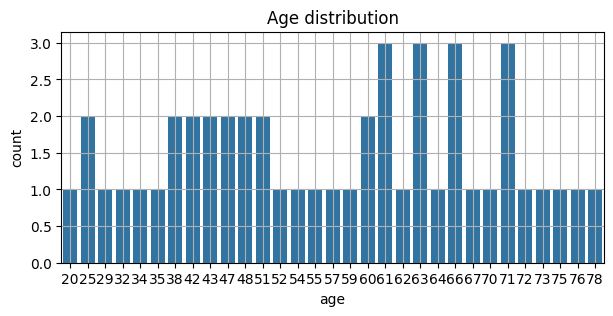

In [9]:
plt.figure(figsize=(7,3))
sns.countplot(data=table_data, x='age')
plt.title('Age distribution')
plt.grid()
plt.show()

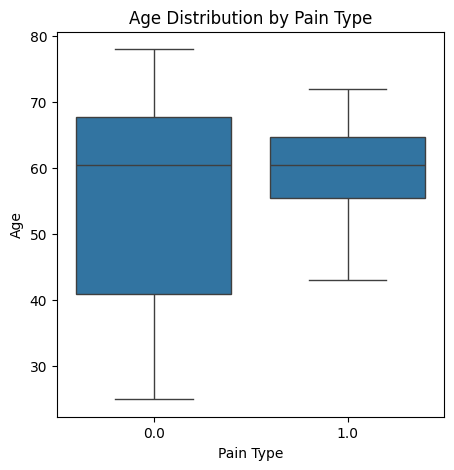

In [10]:
plt.figure(figsize=(5, 5))
sns.boxplot(data=table_data, x='pain_type', y='age')
plt.title('Age Distribution by Pain Type')
plt.xlabel('Pain Type')
plt.ylabel('Age')
plt.show()

In [11]:
for col in table_data.columns:
    if col != 'patient_id': # Exclude 'patient_id' from conversion
        # Ensure the column is treated as string before replacement to avoid errors on mixed types
        table_data[col] = table_data[col].astype(str).str.replace(',', '.', regex=False)
        # Convert to numeric, coercing errors to NaN
        table_data[col] = pd.to_numeric(table_data[col], errors='coerce')

        # Impute missing values with the mean if any NaNs are present after conversion
        #if table_data[col].isnull().any():
        #    table_data[col] = table_data[col].fillna(table_data[col].mean())

print("table_data DataFrame has been cleaned: columns converted to numeric, comma decimals handled, and missing values imputed with the mean.")
print(table_data.head())


table_data DataFrame has been cleaned: columns converted to numeric, comma decimals handled, and missing values imputed with the mean.
   patient_id  sex  age  pain_type  illnes_month  score_pain_reiting  \
0  patient_ 1    0   72        1.0         324.0                 9.0   
1  patient_ 2    1   60        0.0         120.0                 NaN   
2  patient_ 3    0   54        0.0         312.0                 7.0   
3  patient_ 4    0   25        0.0          60.0                 5.0   
4  patient_ 5    0   42        0.0          24.0                 8.0   

   score_osvestri  score_beck  score_spilberg_person  score_spilberg_anxiety  \
0            58.0        24.0                   64.0                    56.0   
1             NaN         NaN                    NaN                     NaN   
2            38.0         9.0                   45.0                    32.0   
3            22.0         8.0                   43.0                    42.0   
4            48.0        22.0   

/tmp/ipykernel_1457/2646969529.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table_data[col] = table_data[col].astype(str).str.replace(',', '.', regex=False)
/tmp/ipykernel_1457/2646969529.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table_data[col] = pd.to_numeric(table_data[col], errors='coerce')
/tmp/ipykernel_1457/2646969529.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cavea

## Visualize Patient Demographics and Basic Information

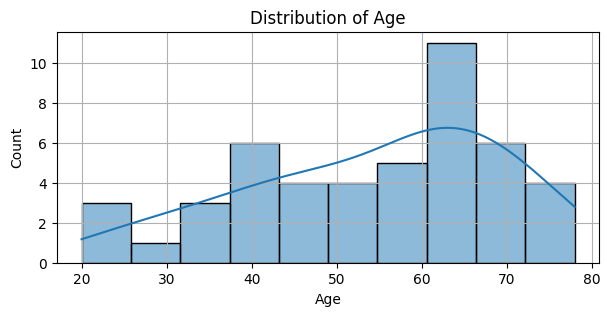

In [12]:
plt.figure(figsize=(7, 3))
sns.histplot(data=table_data, x='age', kde=True, bins=10)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(True)
plt.show()

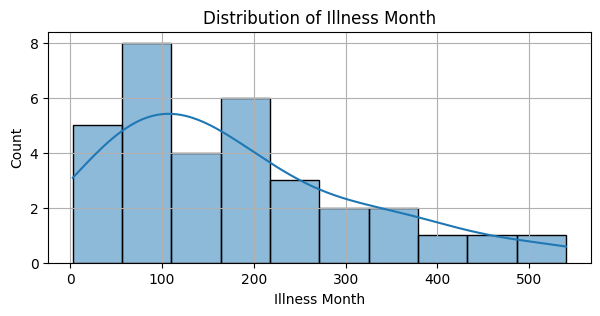

In [13]:
plt.figure(figsize=(7, 3))
sns.histplot(data=table_data, x='illnes_month', kde=True, bins=10)
plt.title('Distribution of Illness Month')
plt.xlabel('Illness Month')
plt.ylabel('Count')
plt.grid(True)
plt.show()

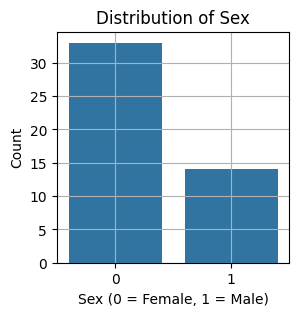

In [14]:
plt.figure(figsize=(3, 3))
sns.countplot(data=table_data, x='sex')
plt.title('Distribution of Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.grid(True)
plt.show()

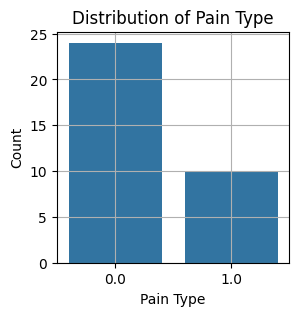

In [15]:
plt.figure(figsize=(3, 3))
sns.countplot(data=table_data[['patient_id','pain_type']].dropna(), x='pain_type')
plt.title('Distribution of Pain Type')
plt.xlabel('Pain Type')
plt.ylabel('Count')
plt.grid(True)
plt.show()

## Visualize Patient Scores Correlation Heatmap


Generate a correlation heatmap for the 'subset_score_columns' (excluding 'patient_id'). This display the Pearson correlation coefficients between the various patient score metrics, highlighting their interrelationships.


Score data prepared for correlation analysis.


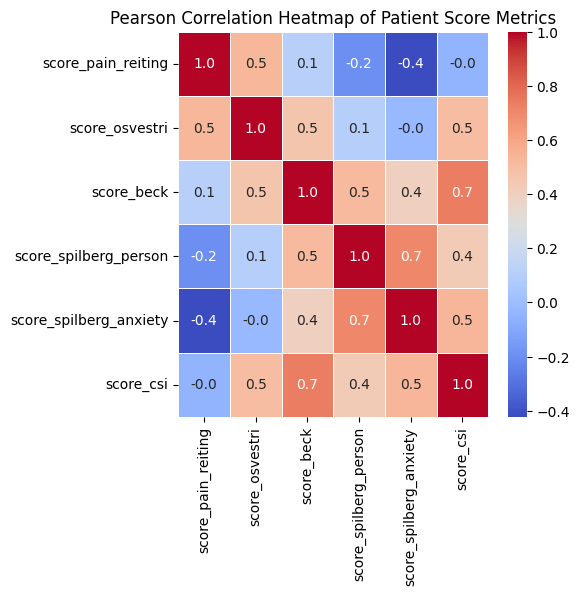

In [16]:
score_data = table_data[subset_score_columns]#.drop('patient_id', axis=1)

print("Score data prepared for correlation analysis.")

correlation_matrix_scores = score_data.corr()

plt.figure(figsize=(5, 5))
sns.heatmap(correlation_matrix_scores, annot=True, cmap='coolwarm', fmt=".1f", linewidths=.5)
plt.title('Pearson Correlation Heatmap of Patient Score Metrics')
plt.show()

## Visualize Diagnosis and Treatment data


In [17]:
diagnosis_data = table_data[subset_dignosis_columns]#.drop('patient_id', axis=1)

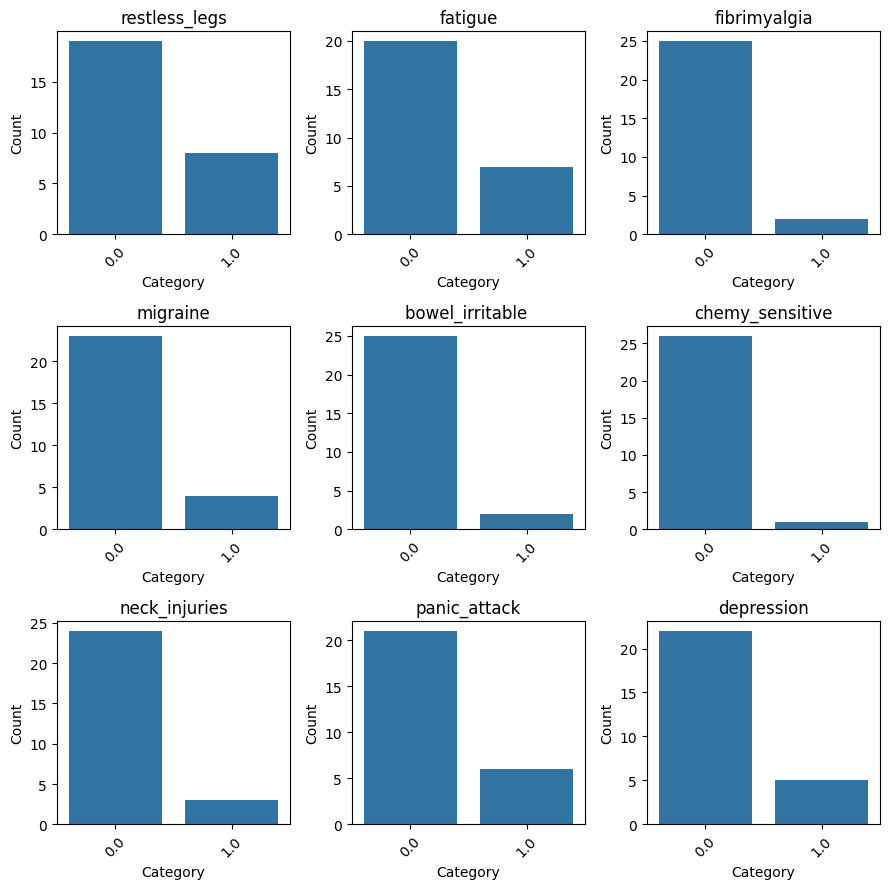

Countplots for diagnosis and treatment features generated.


In [18]:
import math

num_features = diagnosis_data.shape[1]
ncols = 3
nrows = math.ceil(num_features / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3 * ncols, 3 * nrows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(diagnosis_data.columns):
    sns.countplot(data=diagnosis_data, x=col, ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("Countplots for diagnosis and treatment features generated.")

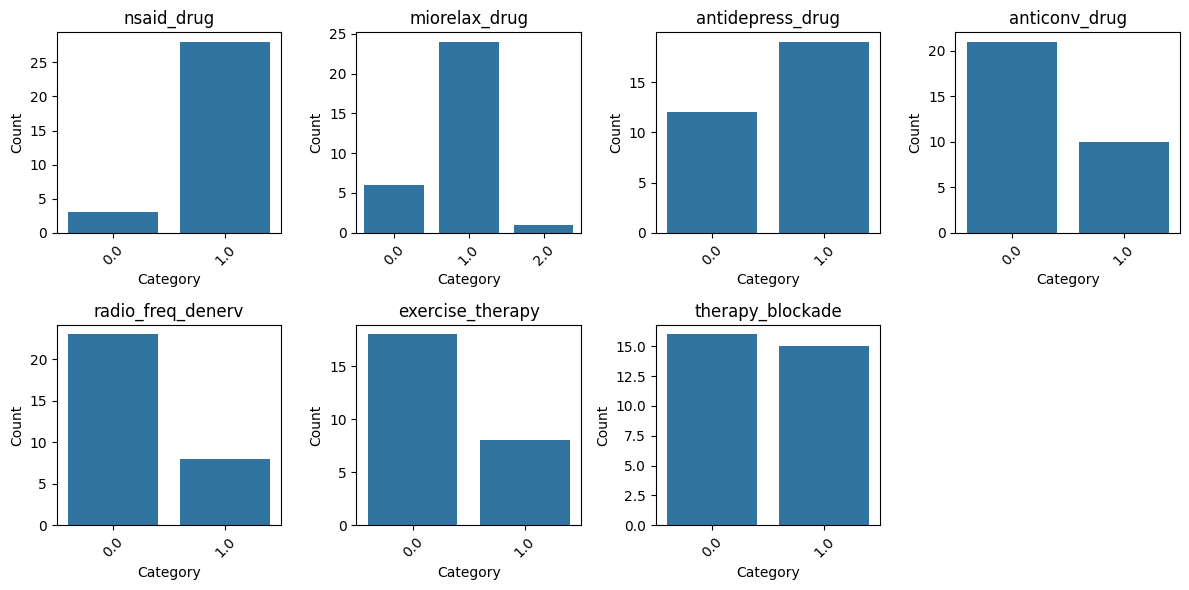

In [19]:
therapy_data = table_data[subset_therapy_columns]#.drop('patient_id', axis=1)

num_features = therapy_data.shape[1]
ncols = 4
nrows = math.ceil(num_features / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3 * ncols, 3 * nrows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(therapy_data.columns):
    sns.countplot(data=therapy_data, x=col, ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Score clustering
Prepare the patient score data by creating a DataFrame from `table_data` using `patient_id` and the columns in `subset_score_columns`. Then, prepare the  patients with complete score data for K-Means clustering by dropping `patient_id`. Normalize this complete score data using `StandardScaler` to ensure all features contribute equally to the clustering process.

In [20]:
score_data_with_id = table_data[subset_score_columns]

#nan_patients = score_data_with_id[score_data_with_id.drop('patient_id', axis=1).isnull().any(axis=1)].copy()
nan_patients = score_data_with_id[score_data_with_id.isnull().any(axis=1)].copy()

#clean_patients = score_data_with_id.dropna(subset=score_data_with_id.drop('patient_id', axis=1).columns).copy()
clean_patients = score_data_with_id.dropna(subset=score_data_with_id.columns).copy()

# Assign 'NaN_Cluster' to patients with missing values
nan_patients['cluster'] = 'NaN_Cluster'

# Prepare clean data for clustering by dropping 'patient_id'
df_clustering_scores = clean_patients#.drop('patient_id', axis=1)

print(f"Patients with missing values (NaN_Cluster): {len(nan_patients)}")
print(f"Patients with complete score data for clustering: {len(clean_patients)}")
#print("First 5 rows of df_clustering_scores (clean data for clustering):")
#print(df_clustering_scores.head())

Patients with missing values (NaN_Cluster): 22
Patients with complete score data for clustering: 25


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled_scores = pd.DataFrame(scaler.fit_transform(df_clustering_scores), columns=df_clustering_scores.columns)


To group patients based on their scores, apply the K-Means clustering algorithm to the scaled data, as specified in the instructions. This involves instantiating KMeans, fitting it to the `df_scaled_scores` DataFrame, and extracting the cluster labels.



In [22]:
from sklearn.cluster import KMeans

n_clusters = 3
kmeans_scores = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Fit the KMeans model to the scaled score data
kmeans_scores.fit(df_scaled_scores)

# Get cluster labels
cluster_labels_scores = kmeans_scores.labels_

print(f"KMeans clustering performed with {n_clusters} clusters on score data.")
print(f"First 5 cluster labels: {cluster_labels_scores[:5]}")

KMeans clustering performed with 3 clusters on score data.
First 5 cluster labels: [2 0 0 1 0]


In [23]:
clean_patients['cluster'] = cluster_labels_scores

all_patients_clustered = pd.concat([clean_patients, nan_patients], ignore_index=True)

all_patients_clustered = all_patients_clustered.rename(columns={'cluster': 'Score_cluster'})

print("Column 'cluster' renamed to 'Score_cluster'.")
#print(all_patients_clustered[['patient_id', 'Score_cluster']].head())

Column 'cluster' renamed to 'Score_cluster'.


In [24]:
print("Distribution of patients across Score_clusters:")
print(all_patients_clustered['Score_cluster'].value_counts())

Distribution of patients across Score_clusters:
Score_cluster
NaN_Cluster    22
0               9
2               8
1               8
Name: count, dtype: int64



*   K-Means clustering was performed on the normalized score data, identifying **3 distinct clusters** (Cluster 0, 1, and 2).
*   The final distribution of patients across the clusters is:
    *   **NaN_Cluster**: 22 patients
    *   **Cluster 2**: 9 patients
    *   **Cluster 1**: 8 patients
    *   **Cluster 0**: 8 patients
*   Approximately **51%** (24 out of 45) of the patients had missing score data, necessitating their exclusion from the K-Means analysis.

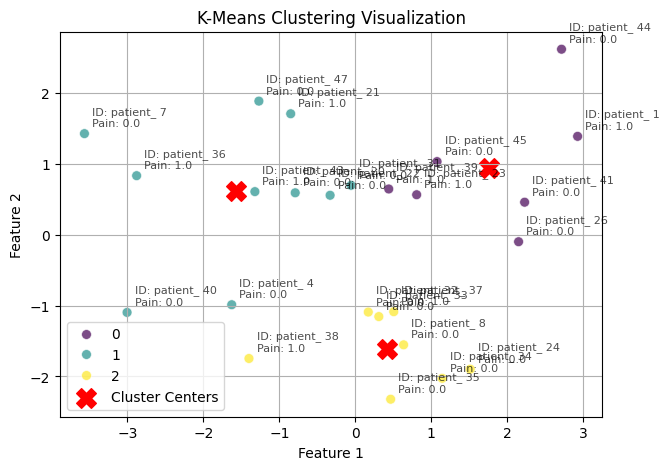

In [25]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2) # Or 3 for 3D visualization
principal_components = pca.fit_transform(df_scaled_scores)
pca_score_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10) # n_init for robust initialization

kmeans.fit(np.array(pca_score_df))
labels = kmeans.predict(np.array(pca_score_df))
cluster_centers = kmeans.cluster_centers_

# Add patient_id and pain_type to pca_score_df for annotation
# Correctly get patient_id from original table_data using clean_patients' index
pca_score_df['patient_id'] = table_data.loc[clean_patients.index, 'patient_id'].values
pca_score_df['cluster_label'] = labels

# Create a temporary DataFrame with the correct 'patient_id' and 'pain_type' from table_data
# using the indices of the clean_patients to ensure alignment.
temp_for_merge = table_data.loc[clean_patients.index, ['patient_id', 'pain_type']].copy()
# The column names are already correct, no need to reassign: temp_for_merge.columns = ['patient_id', 'pain_type']

pca_score_df = pd.merge(pca_score_df, temp_for_merge, on='patient_id', how='left')


# 3. Create the Scatter Plot
plt.figure(figsize=(7, 5))

# Plot data points, colored by cluster label
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster_label',
    palette='viridis',
    data=pca_score_df,
    legend='full',
    s=50,
    alpha=0.7
)

# Plot cluster centers
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], c='red', s=200, marker='X', label='Cluster Centers')


# Add labels for patient_id and pain_type
for i, row in pca_score_df.iterrows():
    plt.text(row['PC1'] + 0.1, row['PC2'] + 0.1,
             f"ID: {row['patient_id']}\nPain: {row['pain_type']}", # Display patient_id and pain_type
             fontsize=8, alpha=0.7)

# 4. Add Labels and Title
plt.title('K-Means Clustering Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
pca.explained_variance_ratio_

array([0.47686053, 0.30716749])

## Dendrogram clustering

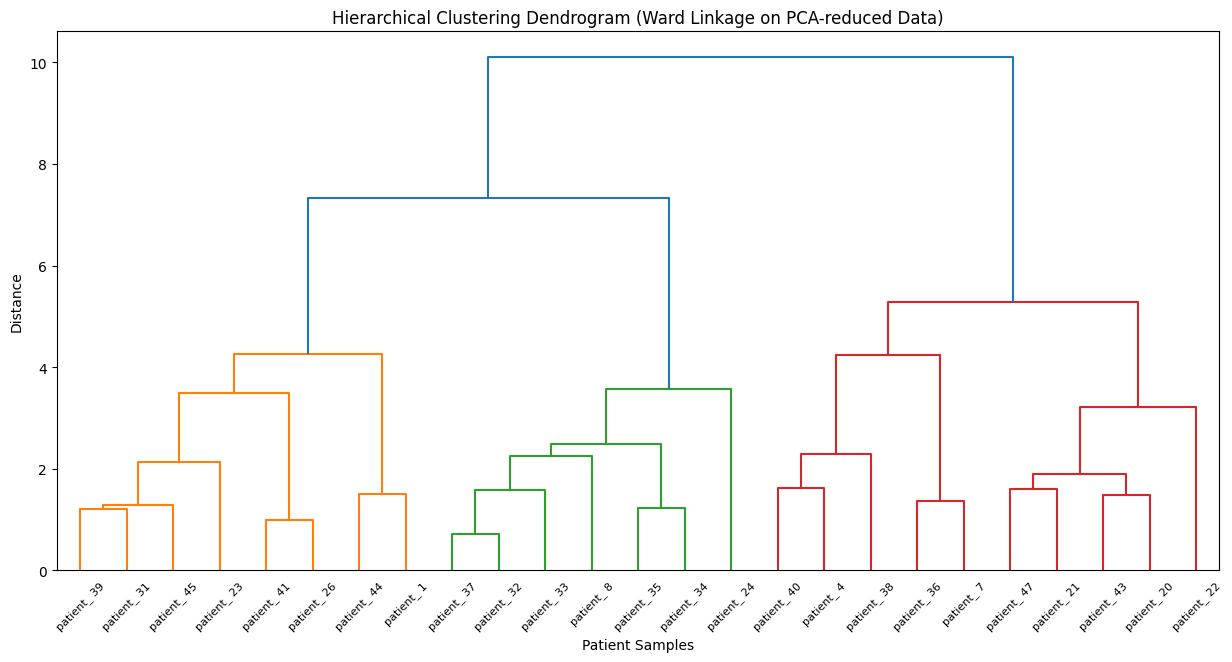

Dendrogram with 'ward' linkage on PCA-reduced data generated.


In [27]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Get patient_ids for labeling the dendrogram
# Use patient_ids from clean_patients, as df_scaled_scores is derived from it
patient_ids_for_dendrogram = clean_patients.index.map(raw_data['patient_id']).tolist()

# Generate the linkage matrix using 'ward' method on the PCA-reduced data
linked_ward_pca = linkage(df_scaled_scores, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(linked_ward_pca,
           orientation='top',
           labels=patient_ids_for_dendrogram,
           distance_sort='descending',
           show_leaf_counts=True,
           leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage on PCA-reduced Data)')
plt.xlabel('Patient Samples')
plt.ylabel('Distance')
plt.show()

print("Dendrogram with 'ward' linkage on PCA-reduced data generated.")

#Case 1: Linear Regression model classification

In [28]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import silhouette_score, classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.svm import LinearSVC
from mpl_toolkits import mplot3d
from tqdm import tqdm

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

In [29]:
table_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      47 non-null     object 
 1   sex                             47 non-null     int64  
 2   age                             47 non-null     int64  
 3   pain_type                       34 non-null     float64
 4   illnes_month                    33 non-null     float64
 5   score_pain_reiting              30 non-null     float64
 6   score_osvestri                  30 non-null     float64
 7   score_beck                      28 non-null     float64
 8   score_spilberg_person           30 non-null     float64
 9   score_spilberg_anxiety          30 non-null     float64
 10  score_csi                       27 non-null     float64
 11  restless_legs                   27 non-null     float64
 12  fatigue                         27 non

In [30]:
table_data_linear_model = table_data.dropna()
# Ensure all 'patient_id' columns are dropped
table_data_linear_model = table_data_linear_model.loc[:, ~table_data_linear_model.columns.duplicated()]
table_data_linear_model = table_data_linear_model.drop('patient_id', axis=1, errors='ignore')

# Re-apply cleaning for comma-separated decimals and conversion to numeric types
for col in table_data_linear_model.columns:
    # Only process columns that are not already numeric
    if table_data_linear_model[col].dtype == 'object':
        table_data_linear_model[col] = table_data_linear_model[col].astype(str).str.replace(',', '.', regex=False)
        table_data_linear_model[col] = pd.to_numeric(table_data_linear_model[col], errors='coerce')

# After converting to numeric, drop rows with any remaining NaNs introduced by 'coerce' if desired
table_data_linear_model = table_data_linear_model.dropna()

table_data_linear_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 0 to 44
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   sex                             20 non-null     int64  
 1   age                             20 non-null     int64  
 2   pain_type                       20 non-null     float64
 3   illnes_month                    20 non-null     float64
 4   score_pain_reiting              20 non-null     float64
 5   score_osvestri                  20 non-null     float64
 6   score_beck                      20 non-null     float64
 7   score_spilberg_person           20 non-null     float64
 8   score_spilberg_anxiety          20 non-null     float64
 9   score_csi                       20 non-null     float64
 10  restless_legs                   20 non-null     float64
 11  fatigue                         20 non-null     float64
 12  fibrimyalgia                    20 non-null

In [31]:
X_clf = table_data_linear_model.drop('pain_type', axis=1)
y_clf = table_data_linear_model['pain_type']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_c = StandardScaler()
X_train_csc = scaler_c.fit_transform(X_train_c)
X_test_csc  = scaler_c.transform(X_test_c)

print(f"Train: {X_train_c.shape}  |  Test: {X_test_c.shape}")
print(f"Доля дефолтов в train: {y_train_c.mean():.2%}")
print(f"Доля дефолтов в test:  {y_test_c.mean():.2%}")

Train: (16, 38)  |  Test: (4, 38)
Доля дефолтов в train: 37.50%
Доля дефолтов в test:  25.00%


In [32]:
# Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_csc, y_train_c)

y_pred_log = log_reg.predict(X_test_csc)
y_proba_log = log_reg.predict_proba(X_test_csc)[:, 1]

log_acc = accuracy_score(y_test_c, y_pred_log)
log_prec = precision_score(y_test_c, y_pred_log)
log_rec = recall_score(y_test_c, y_pred_log)
log_f1 = f1_score(y_test_c, y_pred_log)
log_auc = roc_auc_score(y_test_c, y_proba_log)

print("Logistic Regression")
print(f"  Accuracy  = {log_acc:.4f}")
print(f"  Precision = {log_prec:.4f}")
print(f"  Recall    = {log_rec:.4f}")
print(f"  F1-Score  = {log_f1:.4f}")
print(f"  ROC-AUC   = {log_auc:.4f}")

# Коэффициенты
coef_log = pd.DataFrame({
    'feature': X_clf.columns,
    'odds_ratio': np.exp(log_reg.coef_[0])
}).sort_values('odds_ratio', ascending=False)
print("\nОтношение шансов (odds ratio):")
print(coef_log.to_string(index=False))

Logistic Regression
  Accuracy  = 0.5000
  Precision = 0.0000
  Recall    = 0.0000
  F1-Score  = 0.0000
  ROC-AUC   = 0.6667

Отношение шансов (odds ratio):
                       feature  odds_ratio
         score_spilberg_person    1.907255
                       fatigue    1.853591
                 anticonv_drug    1.745342
                           age    1.676872
         avg_avg_respone_right    1.421465
                 restless_legs    1.273491
              antidepress_drug    1.263434
                    nsaid_drug    1.242296
                  fibrimyalgia    1.231295
               threshold_right    1.228484
                score_osvestri    1.204740
            score_pain_reiting    1.118020
             motor_evoked_left    1.101833
            theshold_edge_left    1.050772
    inhibition_threshold_right    1.050772
avg_inhibition_threshold_right    1.050772
                      migraine    1.000000
 avg_inhibition_threshold_left    1.000000
                  illnes_m

In [33]:
# Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=8)
dt_clf.fit(X_train_csc, y_train_c)

y_pred_dt_c  = dt_clf.predict(X_test_csc)
y_proba_dt_c = dt_clf.predict_proba(X_test_csc)[:, 1]

dt_c_acc  = accuracy_score(y_test_c, y_pred_dt_c)
dt_c_prec = precision_score(y_test_c, y_pred_dt_c)
dt_c_rec  = recall_score(y_test_c, y_pred_dt_c)
dt_c_f1   = f1_score(y_test_c, y_pred_dt_c)
dt_c_auc  = roc_auc_score(y_test_c, y_proba_dt_c)

dt_c_train_acc = accuracy_score(y_train_c, dt_clf.predict(X_train_csc))

print("Decision Tree (max_depth=8)")
print(f"  Train Accuracy = {dt_c_train_acc:.4f}")
print(f"  Test  Accuracy = {dt_c_acc:.4f}")
print(f"  Precision      = {dt_c_prec:.4f}")
print(f"  Recall         = {dt_c_rec:.4f}")
print(f"  F1-Score       = {dt_c_f1:.4f}")
print(f"  ROC-AUC        = {dt_c_auc:.4f}")

if dt_c_train_acc - dt_c_acc > 0.05:
    print(" Возможно переобучение (Train >> Test)")

plt.figure(figsize=(8,4))

Decision Tree (max_depth=8)
  Train Accuracy = 1.0000
  Test  Accuracy = 0.5000
  Precision      = 0.3333
  Recall         = 1.0000
  F1-Score       = 0.5000
  ROC-AUC        = 0.6667
 Возможно переобучение (Train >> Test)


<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest (100 деревьев, max_depth=10)
  Accuracy  = 0.7500
  Precision = 0.0000
  Recall    = 0.0000
  F1-Score  = 0.0000
  ROC-AUC   = 0.6667


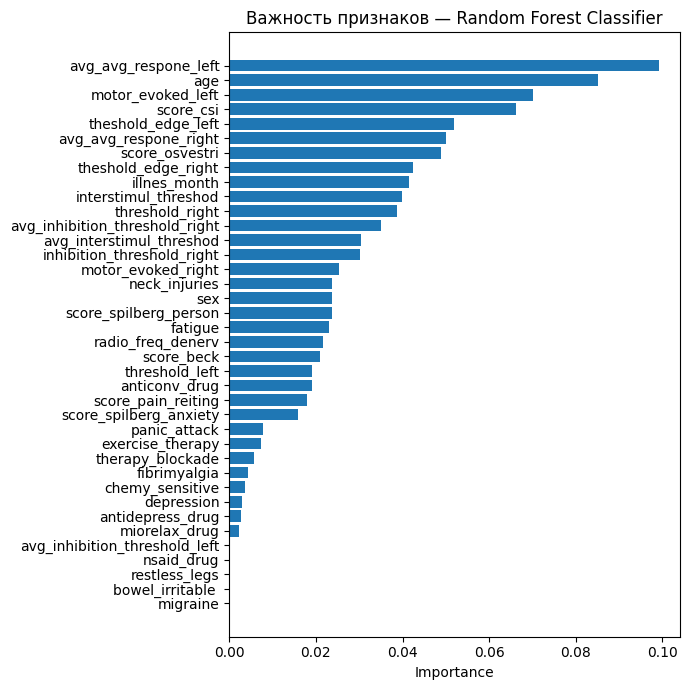

In [34]:
# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_clf.fit(X_train_csc, y_train_c)

y_pred_rf_c  = rf_clf.predict(X_test_csc)
y_proba_rf_c = rf_clf.predict_proba(X_test_csc)[:, 1]

rf_c_acc  = accuracy_score(y_test_c, y_pred_rf_c)
rf_c_prec = precision_score(y_test_c, y_pred_rf_c)
rf_c_rec  = recall_score(y_test_c, y_pred_rf_c)
rf_c_f1   = f1_score(y_test_c, y_pred_rf_c)
rf_c_auc  = roc_auc_score(y_test_c, y_proba_rf_c)

print("Random Forest (100 деревьев, max_depth=10)")
print(f"  Accuracy  = {rf_c_acc:.4f}")
print(f"  Precision = {rf_c_prec:.4f}")
print(f"  Recall    = {rf_c_rec:.4f}")
print(f"  F1-Score  = {rf_c_f1:.4f}")
print(f"  ROC-AUC   = {rf_c_auc:.4f}")

# Важность признаков
feat_imp_clf = pd.DataFrame({
    'feature': X_clf.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(7, 7))
plt.barh(feat_imp_clf['feature'], feat_imp_clf['importance'])
plt.title('Важность признаков — Random Forest Classifier')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [35]:
# Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
gb_clf.fit(X_train_csc, y_train_c)

y_pred_gb_c  = gb_clf.predict(X_test_csc)
y_proba_gb_c = gb_clf.predict_proba(X_test_csc)[:, 1]

gb_c_acc  = accuracy_score(y_test_c, y_pred_gb_c)
gb_c_prec = precision_score(y_test_c, y_pred_gb_c)
gb_c_rec  = recall_score(y_test_c, y_pred_gb_c)
gb_c_f1   = f1_score(y_test_c, y_pred_gb_c)
gb_c_auc  = roc_auc_score(y_test_c, y_proba_gb_c)

print("Gradient Boosting (100 деревьев, max_depth=5)")
print(f"  Accuracy  = {gb_c_acc:.4f}")
print(f"  Precision = {gb_c_prec:.4f}")
print(f"  Recall    = {gb_c_rec:.4f}")
print(f"  F1-Score  = {gb_c_f1:.4f}")
print(f"  ROC-AUC   = {gb_c_auc:.4f}")

Gradient Boosting (100 деревьев, max_depth=5)
  Accuracy  = 0.7500
  Precision = 0.5000
  Recall    = 1.0000
  F1-Score  = 0.6667
  ROC-AUC   = 0.8333


In [36]:
# Support Vector Machine
svm_clf = SVC(probability=True, random_state=42)
svm_clf.fit(X_train_csc, y_train_c)

y_pred_svm  = svm_clf.predict(X_test_csc)
y_proba_svm = svm_clf.predict_proba(X_test_csc)[:, 1]

svm_acc  = accuracy_score(y_test_c, y_pred_svm)
svm_prec = precision_score(y_test_c, y_pred_svm)
svm_rec  = recall_score(y_test_c, y_pred_svm)
svm_f1   = f1_score(y_test_c, y_pred_svm)
svm_auc  = roc_auc_score(y_test_c, y_proba_svm)

print("SVM (RBF kernel)")
print(f"  Accuracy  = {svm_acc:.4f}")
print(f"  Precision = {svm_prec:.4f}")
print(f"  Recall    = {svm_rec:.4f}")
print(f"  F1-Score  = {svm_f1:.4f}")
print(f"  ROC-AUC   = {svm_auc:.4f}")

SVM (RBF kernel)
  Accuracy  = 0.7500
  Precision = 0.0000
  Recall    = 0.0000
  F1-Score  = 0.0000
  ROC-AUC   = 0.3333


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Сводная таблица — Классификация:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression      0.50     0.0000     0.0    0.0000   0.6667
Decision Tree            0.50     0.3333     1.0    0.5000   0.6667
Random Forest            0.75     0.0000     0.0    0.0000   0.6667
Gradient Boosting        0.75     0.5000     1.0    0.6667   0.8333
SVM                      0.75     0.0000     0.0    0.0000   0.3333

Лучшая модель по ROC-AUC: Gradient Boosting (0.8333)


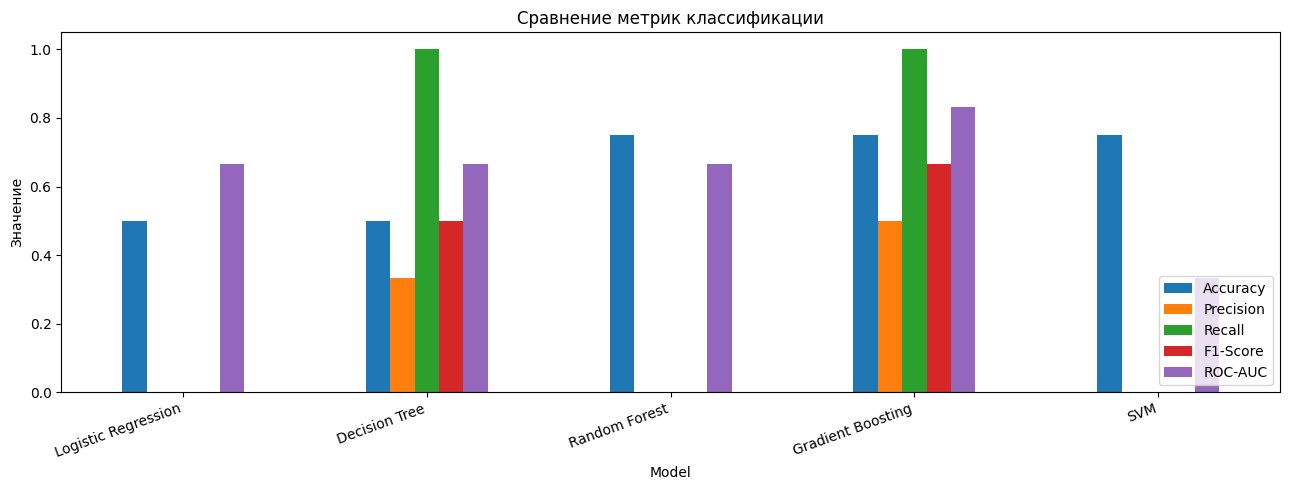

In [37]:
# сравниваем разные методы классификаци
clf_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree',
              'Random Forest', 'Gradient Boosting', 'SVM'],
    'Accuracy':  [log_acc,  dt_c_acc,  rf_c_acc,  gb_c_acc,  svm_acc],
    'Precision': [log_prec, dt_c_prec, rf_c_prec, gb_c_prec, svm_prec],
    'Recall':    [log_rec,  dt_c_rec,  rf_c_rec,  gb_c_rec,  svm_rec],
    'F1-Score':  [log_f1,   dt_c_f1,   rf_c_f1,   gb_c_f1,   svm_f1],
    'ROC-AUC':   [log_auc,  dt_c_auc,  rf_c_auc,  gb_c_auc,  svm_auc]
}).set_index('Model').round(4)

print("Сводная таблица — Классификация:")
print(clf_summary.to_string())

best_clf = clf_summary['ROC-AUC'].idxmax()
print(f"\nЛучшая модель по ROC-AUC: {best_clf} ({clf_summary.loc[best_clf, 'ROC-AUC']:.4f})")

# График метрик
clf_summary.plot(kind='bar', figsize=(13, 5))
plt.title('Сравнение метрик классификации')
plt.ylabel('Значение')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

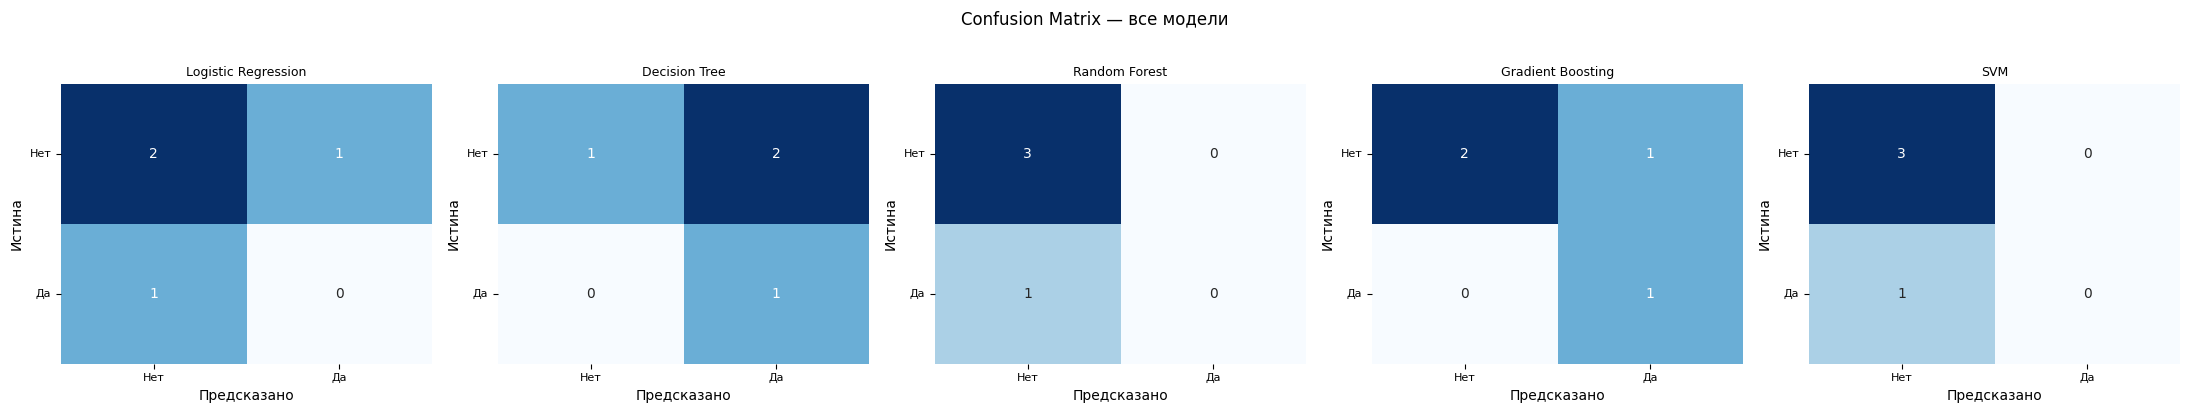

In [38]:
# выводим матрицу ошибок
# матрица ошибок для каждой модели
models_preds = {
    'Logistic Regression': (y_pred_log,  y_proba_log),
    'Decision Tree':       (y_pred_dt_c, y_proba_dt_c),
    'Random Forest':       (y_pred_rf_c, y_proba_rf_c),
    'Gradient Boosting':   (y_pred_gb_c, y_proba_gb_c),
    'SVM':                 (y_pred_svm,  y_proba_svm)
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, (y_pred, _)) in zip(axes, models_preds.items()):
    cm = confusion_matrix(y_test_c, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истина')
    ax.set_xticklabels(['Нет', 'Да'], fontsize=8)
    ax.set_yticklabels(['Нет', 'Да'], fontsize=8, rotation=0)
plt.suptitle('Confusion Matrix — все модели', y=1.02)
plt.tight_layout()
plt.show()

# Check statistical significance

## statistical significance for Linear Model Classification

**Conclusion on Statistical Significance**

Based on the statistical tests (Mann-Whitney U for continuous features and Chi-squared for binary-like features) comparing `pain_type` 0.0 and 1.0, **none of the analyzed features show a statistically significant difference** between the two groups at a conventional alpha level of 0.05.

*   All p-values are greater than 0.05, indicating that we **do not have sufficient evidence to reject the null hypothesis** that there is no difference in the feature distributions between `pain_type` 0.0 and 1.0.
*   One feature, `avg_inhibition_threshold_left`, was skipped due to insufficient variance or data, making a statistical comparison impossible.

This outcome suggests that, when analyzed individually, these features may not be strong discriminators for `pain_type` 0.0 versus 1.0 within this dataset. It's possible that the differences are subtle, manifest in multivariate combinations, or require a larger sample size to detect.

In [39]:
from scipy.stats import mannwhitneyu, chi2_contingency

# Separate data by pain_type
group_0 = table_data_linear_model[table_data_linear_model['pain_type'] == 0.0]
group_1 = table_data_linear_model[table_data_linear_model['pain_type'] == 1.0]

print("Statistical Significance of Features for Pain Type 0 vs 1:\n")

results = []

for col in X_clf.columns:
    feature_data_0 = group_0[col]
    feature_data_1 = group_1[col]

    # Check for constant features or insufficient data in groups
    if len(feature_data_0.dropna()) < 2 or len(feature_data_1.dropna()) < 2 or feature_data_0.nunique() == 1 and feature_data_1.nunique() == 1:
        results.append({'Feature': col, 'Test': 'Skipped (insufficient variance/data)', 'P-value': 'N/A'})
        continue

    # Heuristic to determine if a column is effectively binary/categorical (e.g., 0/1)
    is_binary_like = False
    unique_vals = pd.concat([feature_data_0, feature_data_1]).dropna().unique()
    if len(unique_vals) <= 2 and all(val in [0, 1] for val in unique_vals):
        is_binary_like = True

    if is_binary_like:
        # Chi-squared test for binary features
        contingency_table = pd.crosstab(table_data_linear_model['pain_type'], table_data_linear_model[col])
        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2 or contingency_table.sum().sum() == 0:
             results.append({'Feature': col, 'Test': 'Skipped (Chi-squared invalid)', 'P-value': 'N/A'})
             continue

        try:
            chi2, p_val, _, _ = chi2_contingency(contingency_table)
            results.append({'Feature': col, 'Test': 'Chi-squared', 'P-value': f'{p_val:.4f}'})
        except ValueError:
            results.append({'Feature': col, 'Test': 'Chi-squared (error)', 'P-value': 'N/A'})

    else:
        # Mann-Whitney U test for continuous numerical features
        # Drop NaNs for the test
        clean_feature_data_0 = feature_data_0.dropna()
        clean_feature_data_1 = feature_data_1.dropna()

        if len(clean_feature_data_0) == 0 or len(clean_feature_data_1) == 0:
            results.append({'Feature': col, 'Test': 'Skipped (no data for group)', 'P-value': 'N/A'})
            continue

        statistic, p_val = mannwhitneyu(clean_feature_data_0, clean_feature_data_1, alternative='two-sided')
        results.append({'Feature': col, 'Test': 'Mann-Whitney U', 'P-value': f'{p_val:.4f}'})

Statistical Significance of Features for Pain Type 0 vs 1:



In [40]:
results_df = pd.DataFrame(results)
print("Statistical Significance of Features for Pain Type 0 vs 1:")
print(results_df.to_string(index=False))

Statistical Significance of Features for Pain Type 0 vs 1:
                       Feature                                 Test P-value
                           sex                          Chi-squared  0.1017
                           age                       Mann-Whitney U  0.3407
                  illnes_month                       Mann-Whitney U  0.1894
            score_pain_reiting                       Mann-Whitney U  0.3337
                score_osvestri                       Mann-Whitney U  0.1646
                    score_beck                       Mann-Whitney U  1.0000
         score_spilberg_person                       Mann-Whitney U  0.7810
        score_spilberg_anxiety                       Mann-Whitney U  1.0000
                     score_csi                       Mann-Whitney U  0.6627
                 restless_legs                          Chi-squared  0.6824
                       fatigue                          Chi-squared  0.1973
                  fibrimyalgi

## Statistical significance for zero-shot classification

In [41]:
link_url = 'https://raw.githubusercontent.com/TAUforPython/TMS-pain-analysis/refs/heads/main/test_datasets/tms_timeseries_clusters.csv'

df = pd.read_csv(link_url, sep = ',', index_col=0)
df.head(5)


,patient_id,Avg_Resp_Left_Mean,Avg_Resp_Left_Std,Avg_Resp_Left_Hurst_MFDFA,Avg_Resp_Left_Hurst_RS,Avg_Resp_Right_Mean,Avg_Resp_Right_Std,Avg_Resp_Right_Hurst_MFDFA,Avg_Resp_Right_Hurst_RS,Avg_Resp_DTW_Cluster,Avg_Resp_DWT_Cluster,Inh_Thresh_DTW_Cluster,Inh_Thresh_DWT_Cluster,pain_type
0,patient_ 1n,53.259528,12.009135,0.397920,0.874743,194.736574,40.132561,1.917325,0.814841,2,2,1,1,2.0
1,patient_ 2n,123.597025,41.771269,1.163941,0.804984,109.284255,41.218117,1.462129,0.848242,1,1,1,1,2.0
2,patient_ 3n,39.701583,21.652062,1.099086,0.808963,84.205208,32.102390,1.186651,0.872955,1,1,1,1,2.0
3,patient_ 4n,73.540167,23.046395,0.802684,0.753236,64.819444,13.978575,1.351294,0.820057,1,1,1,2,2.0
4,patient_ 5n,100.746296,14.629567,0.809085,0.694620,38.125000,10.383945,0.789748,0.722638,1,1,1,2,2.0


In [42]:
df.describe()

,Avg_Resp_Left_Mean,Avg_Resp_Left_Std,Avg_Resp_Left_Hurst_MFDFA,Avg_Resp_Left_Hurst_RS,Avg_Resp_Right_Mean,Avg_Resp_Right_Std,Avg_Resp_Right_Hurst_MFDFA,Avg_Resp_Right_Hurst_RS,Avg_Resp_DTW_Cluster,Avg_Resp_DWT_Cluster,Inh_Thresh_DTW_Cluster,Inh_Thresh_DWT_Cluster,pain_type
count,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,97.575992,31.392067,1.335091,0.790429,92.775556,26.918328,1.246598,0.807189,0.918033,1.065574,0.868852,0.868852,1.114754
std,48.567160,20.193651,0.479255,0.081061,42.594351,14.670148,0.439197,0.068411,0.585807,0.512148,0.784759,0.939422,0.914665
min,17.563361,5.387014,0.237006,0.591424,27.759094,6.595104,0.206150,0.613203,0.000000,0.000000,0.000000,0.000000,0.000000
25%,64.550536,17.719056,0.965192,0.721033,61.637611,17.269070,0.960461,0.768800,1.000000,1.000000,0.000000,0.000000,0.000000
50%,85.810278,24.536111,1.394655,0.811061,81.922902,23.023221,1.246963,0.812484,1.000000,1.000000,1.000000,0.000000,1.000000
75%,115.579444,39.732063,1.729370,0.854883,114.217722,33.402141,1.517855,0.858348,1.000000,1.000000,1.000000,2.000000,2.000000
max,229.808333,96.455250,2.059395,0.912607,198.331591,86.465844,2.118199,0.925542,2.000000,2.000000,2.000000,2.000000,2.000000


In [43]:
X_clf = df.drop(['pain_type','patient_id','Avg_Resp_DTW_Cluster',	'Avg_Resp_DWT_Cluster',	'Inh_Thresh_DTW_Cluster',	'Inh_Thresh_DWT_Cluster','Avg_Resp_Right_Hurst_MFDFA','Avg_Resp_Left_Hurst_MFDFA'], axis=1)
y_clf = df['pain_type']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_c = StandardScaler()
X_train_csc = scaler_c.fit_transform(X_train_c)
X_test_csc  = scaler_c.transform(X_test_c)

print(f"Train: {X_train_c.shape}  |  Test: {X_test_c.shape}")
print(f"Доля в train: {y_train_c.mean():.2%}")
print(f"Доля в test:  {y_test_c.mean():.2%}")

Train: (48, 6)  |  Test: (13, 6)
Доля в train: 112.50%
Доля в test:  107.69%


In [44]:
X_clf

,Avg_Resp_Left_Mean,Avg_Resp_Left_Std,Avg_Resp_Left_Hurst_RS,Avg_Resp_Right_Mean,Avg_Resp_Right_Std,Avg_Resp_Right_Hurst_RS
0,53.259528,12.009135,0.874743,194.736574,40.132561,0.814841
1,123.597025,41.771269,0.804984,109.284255,41.218117,0.848242
2,39.701583,21.652062,0.808963,84.205208,32.102390,0.872955
3,73.540167,23.046395,0.753236,64.819444,13.978575,0.820057
4,100.746296,14.629567,0.694620,38.125000,10.383945,0.722638
...,...,...,...,...,...,...
56,76.422778,22.373236,0.882637,66.449074,14.436201,0.862425
57,83.317560,18.023992,0.718763,76.647917,28.206003,0.858348
58,86.609226,24.699766,0.803029,61.637611,23.023425,0.856157
59,98.417887,16.433997,0.691572,89.208167,25.067659,0.911943


In [45]:
# Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
gb_clf.fit(X_train_csc, y_train_c)

y_pred_gb_c  = gb_clf.predict(X_test_csc)
y_proba_gb_c = gb_clf.predict_proba(X_test_csc)[:, 1] # Note: predict_proba for multiclass returns probabilities for each class

gb_c_acc  = accuracy_score(y_test_c, y_pred_gb_c)
gb_c_prec = precision_score(y_test_c, y_pred_gb_c, average='weighted')
gb_c_rec  = recall_score(y_test_c, y_pred_gb_c, average='weighted')
gb_c_f1   = f1_score(y_test_c, y_pred_gb_c, average='weighted')
# For ROC-AUC in multiclass, it's often calculated per-class or one-vs-rest. For simplicity, we'll keep the binary approach if the 'positive' class is relevant, or calculate for one-vs-rest.
# Given y_proba_gb_c[:, 1] was previously used, assuming pain_type 1.0 is the positive class, if that's incorrect, this needs adjustment.
# For proper multiclass AUC, consider roc_auc_score(y_test_c, y_proba_gb_c, multi_class='ovr', average='weighted')
# For now, keeping the single-class probability if the intent was specific to class 1.
# Re-evaluating based on y_proba_gb_c which has 3 columns, we should calculate multi_class AUC.
gb_c_auc  = roc_auc_score(y_test_c, gb_clf.predict_proba(X_test_csc), multi_class='ovr', average='weighted')

print("Gradient Boosting (100 деревьев, max_depth=5)")
print(f"  Accuracy  = {gb_c_acc:.4f}")
print(f"  Precision = {gb_c_prec:.4f}")
print(f"  Recall    = {gb_c_rec:.4f}")
print(f"  F1-Score  = {gb_c_f1:.4f}")
print(f"  ROC-AUC   = {gb_c_auc:.4f}")

Gradient Boosting (100 деревьев, max_depth=5)
  Accuracy  = 0.6923
  Precision = 0.6813
  Recall    = 0.6923
  F1-Score  = 0.6760
  ROC-AUC   = 0.8146


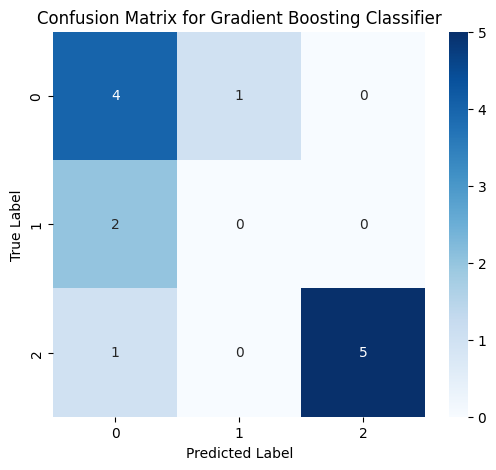

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_gb_c = confusion_matrix(y_test_c, y_pred_gb_c)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb_c, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Gradient Boosting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Statistical significance for combined HMS classification

In [47]:
# Обозначения
L_M = df['Avg_Resp_Left_Mean']
L_S = df['Avg_Resp_Left_Std']
L_H = df['Avg_Resp_Left_Hurst_RS']

R_M = df['Avg_Resp_Right_Mean']
R_S = df['Avg_Resp_Right_Std']
R_H = df['Avg_Resp_Right_Hurst_RS']

eps = 0

# Новая комбинация: нормированная асимметрия по H, M, S
asym_H = (R_H - L_H) / (R_H + L_H + eps)
asym_M = (R_M - L_M) / (R_M + L_M + eps)
asym_S = (R_S - L_S) / (R_S + L_S + eps)

combined_HMS_score_series = asym_H + asym_M + asym_S

X_clf = pd.DataFrame({
    'pain_type': df['pain_type'],
    'combined_HMS_score': combined_HMS_score_series
})


In [48]:
y_clf = df['pain_type']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_c = StandardScaler()
X_train_csc = scaler_c.fit_transform(X_train_c)
X_test_csc  = scaler_c.transform(X_test_c)

print(f"Train: {X_train_c.shape}  |  Test: {X_test_c.shape}")
print(f"Доля в train: {y_train_c.mean():.2%}")
print(f"Доля в test:  {y_test_c.mean():.2%}")

Train: (48, 2)  |  Test: (13, 2)
Доля в train: 112.50%
Доля в test:  107.69%


In [49]:
# Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
gb_clf.fit(X_train_csc, y_train_c)

y_pred_gb_c  = gb_clf.predict(X_test_csc)
y_proba_gb_c = gb_clf.predict_proba(X_test_csc)[:, 1] # Note: predict_proba for multiclass returns probabilities for each class

gb_c_acc  = accuracy_score(y_test_c, y_pred_gb_c)
gb_c_prec = precision_score(y_test_c, y_pred_gb_c, average='weighted')
gb_c_rec  = recall_score(y_test_c, y_pred_gb_c, average='weighted')
gb_c_f1   = f1_score(y_test_c, y_pred_gb_c, average='weighted')
# For ROC-AUC in multiclass, it's often calculated per-class or one-vs-rest. For simplicity, we'll keep the binary approach if the 'positive' class is relevant, or calculate for one-vs-rest.
# Given y_proba_gb_c[:, 1] was previously used, assuming pain_type 1.0 is the positive class, if that's incorrect, this needs adjustment.
# For proper multiclass AUC, consider roc_auc_score(y_test_c, y_proba_gb_c, multi_class='ovr', average='weighted')
# For now, keeping the single-class probability if the intent was specific to class 1.
# Re-evaluating based on y_proba_gb_c which has 3 columns, we should calculate multi_class AUC.
gb_c_auc  = roc_auc_score(y_test_c, gb_clf.predict_proba(X_test_csc), multi_class='ovr', average='weighted')

print("Gradient Boosting (100 деревьев, max_depth=5)")
print(f"  Accuracy  = {gb_c_acc:.4f}")
print(f"  Precision = {gb_c_prec:.4f}")
print(f"  Recall    = {gb_c_rec:.4f}")
print(f"  F1-Score  = {gb_c_f1:.4f}")
print(f"  ROC-AUC   = {gb_c_auc:.4f}")

Gradient Boosting (100 деревьев, max_depth=5)
  Accuracy  = 1.0000
  Precision = 1.0000
  Recall    = 1.0000
  F1-Score  = 1.0000
  ROC-AUC   = 1.0000


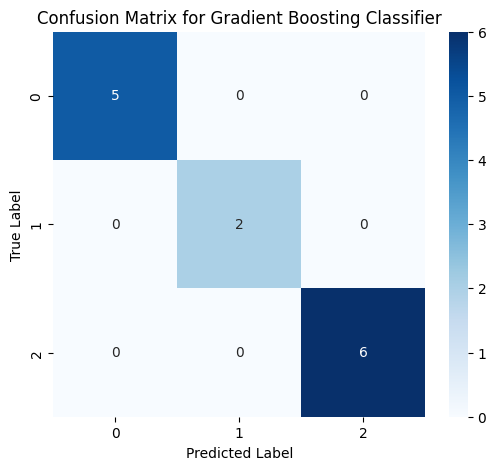

In [50]:
cm_gb_c = confusion_matrix(y_test_c, y_pred_gb_c)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb_c, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Gradient Boosting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Compute p-value

In [51]:
from scipy.stats import kruskal

=== Тест для комбинации Hurst + Mean + Std ===
Название признака: combined_HMS_score
Формула: asym(H) + asym(M) + asym(S)
Kruskal–Wallis H = 6.2957, p = 0.04294
✅ СТАТИСТИЧЕСКИ ЗНАЧИМО (p < 0.05)


/tmp/ipykernel_1457/2023940066.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pain_type', y='combined_HMS_score', palette='Set2')


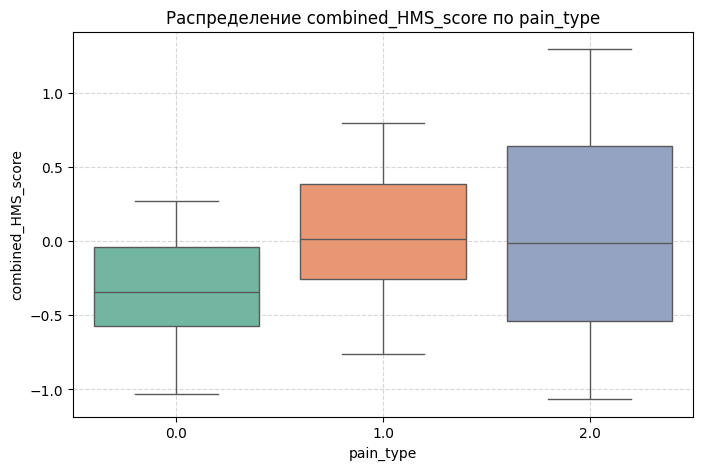


=== Медианы по группам ===
pain_type = 0: медиана = -0.3409
pain_type = 1: медиана = 0.0128
pain_type = 2: медиана = -0.0120


In [52]:

# Удалим строки с пропусками
df = df.dropna(subset=[
    'Avg_Resp_Left_Mean', 'Avg_Resp_Left_Std', 'Avg_Resp_Left_Hurst_RS',
    'Avg_Resp_Right_Mean', 'Avg_Resp_Right_Std', 'Avg_Resp_Right_Hurst_RS',
    'pain_type'
])

# Обозначения
L_M = df['Avg_Resp_Left_Mean']
L_S = df['Avg_Resp_Left_Std']
L_H = df['Avg_Resp_Left_Hurst_RS']

R_M = df['Avg_Resp_Right_Mean']
R_S = df['Avg_Resp_Right_Std']
R_H = df['Avg_Resp_Right_Hurst_RS']

eps = 0

# Новая комбинация: нормированная асимметрия по H, M, S
asym_H = (R_H - L_H) / (R_H + L_H + eps)
asym_M = (R_M - L_M) / (R_M + L_M + eps)
asym_S = (R_S - L_S) / (R_S + L_S + eps)

df['combined_HMS_score'] = asym_H + asym_M + asym_S

# Kruskal–Wallis test
groups = [df[df['pain_type'] == pt]['combined_HMS_score'] for pt in sorted(df['pain_type'].unique())]
H_stat, p_val = kruskal(*groups)

print("=== Тест для комбинации Hurst + Mean + Std ===")
print(f"Название признака: combined_HMS_score")
print(f"Формула: asym(H) + asym(M) + asym(S)")
print(f"Kruskal–Wallis H = {H_stat:.4f}, p = {p_val:.5f}")

if p_val < 0.05:
    print("✅ СТАТИСТИЧЕСКИ ЗНАЧИМО (p < 0.05)")
else:
    print("❌ Не значимо")

# Визуализация
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='pain_type', y='combined_HMS_score', palette='Set2')
plt.title('Распределение combined_HMS_score по pain_type')
plt.xlabel('pain_type')
plt.ylabel('combined_HMS_score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Описательная статистика
print("\n=== Медианы по группам ===")
for pt in sorted(df['pain_type'].unique()):
    median_val = df[df['pain_type'] == pt]['combined_HMS_score'].median()
    print(f"pain_type = {int(pt)}: медиана = {median_val:.4f}")

In [53]:
from scipy.stats import mannwhitneyu

pain_type_0 = df[df['pain_type'] == 0]['combined_HMS_score'].dropna()
pain_type_1 = df[df['pain_type'] == 1]['combined_HMS_score'].dropna()
pain_type_2 = df[df['pain_type'] == 2]['combined_HMS_score'].dropna()

print("\n--- Попарные U-тесты Манна-Уитни для combined_HMS_score ---")

pairs = [
    (pain_type_0, pain_type_1, 'Тип боли 0 vs Тип боли 1'),
    (pain_type_0, pain_type_2, 'Тип боли 0 vs Тип боли 2 (Здоровые люди)'),
    (pain_type_1, pain_type_2, 'Тип боли 1 vs Тип боли 2 (Здоровые люди)')
]

for group1, group2, label in pairs:
    if len(group1) > 1 and len(group2) > 1: # Убедимся, что данных достаточно для сравнения
        stat, p_val = mannwhitneyu(group1, group2, alternative='two-sided')
        print(f"  {label}: P-значение = {p_val:.5f}")
        if p_val < 0.05:
            print("    ✅ Статистически значимо (p < 0.05)")
        else:
            print("    ❌ Не статистически значимо (p >= 0.05)")
    else:
        print(f"  {label}: Пропущено (недостаточно данных для сравнения)")


print("\n--- Краткое изложение статистической значимости ---")
print("Kruskal-Wallis H-тест (выполненный ранее) показал общую значительную разницу между типами боли 0, 1 и 2. Попарные U-тесты Манна-Уитни помогают определить, какие именно группы вносят вклад в эту общую разницу.")


--- Попарные U-тесты Манна-Уитни для combined_HMS_score ---
  Тип боли 0 vs Тип боли 1: P-значение = 0.04415
    ✅ Статистически значимо (p < 0.05)
  Тип боли 0 vs Тип боли 2 (Здоровые люди): P-значение = 0.02671
    ✅ Статистически значимо (p < 0.05)
  Тип боли 1 vs Тип боли 2 (Здоровые люди): P-значение = 0.91037
    ❌ Не статистически значимо (p >= 0.05)

--- Краткое изложение статистической значимости ---
Kruskal-Wallis H-тест (выполненный ранее) показал общую значительную разницу между типами боли 0, 1 и 2. Попарные U-тесты Манна-Уитни помогают определить, какие именно группы вносят вклад в эту общую разницу.


`combined_HMS_score` объединяет **нормированную межполушарную асимметрию** по трём ключевым характеристикам TMS-ответа:

\[
\text{asym}_X = \frac{X_R - X_L}{X_R + X_L}, \quad X \in \{ \text{Hurst},\ \text{Mean},\ \text{Std} \}
\]

Это — **относительная разность**, выражающая, **насколько одно полушарие отличается от другого в процентах от их общей активности/сложности**.

---

#### 1. **Инвариантность к индивидуальному масштабу**
- У разных пациентов **абсолютные значения** (например, амплитуда ответа) сильно различаются из-за:
  - возраста,
  - толщины черепа,
  - положения катушки,
  - уровня возбудимости коры.
- Использование **относительной разности** устраняет этот источник вариабельности.
- Пример:  
  - Пациент A: `R_M = 200`, `L_M = 100` → `asym_M = (200−100)/(200+100) = 0.33`  
  - Пациент B: `R_M = 40`, `L_M = 20` → `asym_M = (40−20)/(40+20) = 0.33`  
  → **одинаковая относительная асимметрия**, несмотря на разный масштаб.

> Это критически важно для **сравнения между пациентами**.

#### 2. **Интеграция трёх независимых аспектов TMS-ответа**
- **Hurst exponent** — отражает **сложность и долгосрочную зависимость** нейронального ответа (связан с саморегуляцией, стабильностью сети).
- **Mean (амплитуда)** — мера **силы коркового ответа** (возбудимость).
- **Std (стандартное отклонение)** — показатель **вариабельности/стабильности** ответа от стимула к стимулу.
- Комбинирование этих трёх аспектов даёт **целостную картину межполушарного дисбаланса**, а не фокусируется на одном признаке.

#### 3. **Физиологическая интерпретация знака**
- Положительное значение `asym_X` → **правое полушарие выше** по параметру `X`.
- Отрицательное → **левое выше**.
- Сумма `asym_H + asym_M + asym_S` усиливает сигнал, если **асимметрия согласована по нескольким параметрам** (например, правое полушарие и сложнее, и сильнее, и стабильнее).
- Это повышает **чувствительность к патологическим паттернам**, характерным для хронической боли.

#### 4. **Совместимость с нейрофизиологическими моделями**
- В литературе по TMS и хронической боли часто описывают **гиперактивность одного полушария** и **гипоактивность другого** — причём это касается **и амплитуды, и вариабельности, и динамики**.
- Ваш признак **естественным образом ловит такой синхронный дисбаланс**.

---
Признак `combined_HMS_score`:

- **Физиологически мотивирован**: отражает согласованную межполушарную асимметрию по трём ключевым параметрам.
- **Статистически робастен**: инвариантен к масштабу, усиливает согласованный сигнал.
- **Клинически интерпретируем**: положительные/отрицательные значения указывают на доминирование правого/левого полушария.
- **Позволяет выявить скрытые различия** между группами `pain_type`, даже если отдельные признаки не значимы.

Если тест **показал p < 0.05**, вы нашли **интегративный биомаркер**, который может быть использован для **дифференциальной диагностики типов боли** на основе TMS-ответов.

In [54]:
columns_to_exclude = [
    'patient_id', 'Avg_Resp_DTW_Cluster', 'Avg_Resp_DWT_Cluster',
    'Inh_Thresh_DTW_Cluster', 'Inh_Thresh_DWT_Cluster', 'pain_type'
]

# Dynamically get all numerical columns that are not in the exclude list
feature_columns = [col for col in df.select_dtypes(include=np.number).columns if col not in columns_to_exclude]

# Ensure 'combined_HMS_score' is included if it's not already (it should be numerical)
if 'combined_HMS_score' not in feature_columns:
    feature_columns.append('combined_HMS_score')

# Create the df_kruskal DataFrame
df_kruskal = df[feature_columns + ['pain_type']].copy()

# Drop rows with any missing values
df_kruskal.dropna(inplace=True)

print("df_kruskal DataFrame prepared for Kruskal-Wallis test:")
print(df_kruskal.head())
print(df_kruskal.info())

df_kruskal DataFrame prepared for Kruskal-Wallis test:
   Avg_Resp_Left_Mean  Avg_Resp_Left_Std  Avg_Resp_Left_Hurst_MFDFA  \
0           53.259528          12.009135                   0.397920   
1          123.597025          41.771269                   1.163941   
2           39.701583          21.652062                   1.099086   
3           73.540167          23.046395                   0.802684   
4          100.746296          14.629567                   0.809085   

   Avg_Resp_Left_Hurst_RS  Avg_Resp_Right_Mean  Avg_Resp_Right_Std  \
0                0.874743           194.736574           40.132561   
1                0.804984           109.284255           41.218117   
2                0.808963            84.205208           32.102390   
3                0.753236            64.819444           13.978575   
4                0.694620            38.125000           10.383945   

   Avg_Resp_Right_Hurst_MFDFA  Avg_Resp_Right_Hurst_RS  combined_HMS_score  \
0                  

In [55]:
kruskal_results = []

for feature in feature_columns:
    # Get the data for each pain_type group for the current feature
    groups = [df_kruskal[df_kruskal['pain_type'] == pt][feature].dropna() for pt in sorted(df_kruskal['pain_type'].unique())]

    # Only perform Kruskal-Wallis if there are at least two valid groups
    # and each group has at least one observation
    valid_groups = [g for g in groups if not g.empty]
    if len(valid_groups) >= 2:
        try:
            H_stat, p_val = kruskal(*valid_groups)
            kruskal_results.append({'Feature': feature, 'H_statistic': H_stat, 'P_value': p_val})
        except ValueError as e:
            kruskal_results.append({'Feature': feature, 'H_statistic': 'N/A', 'P_value': 'Error: ' + str(e)})
    else:
        kruskal_results.append({'Feature': feature, 'H_statistic': 'N/A', 'P_value': 'Skipped: Insufficient data for groups'})

results_df = pd.DataFrame(kruskal_results)

print("\n--- Kruskal-Wallis H-test Results ---")
print(results_df.to_string(index=False))

significant_features = results_df[results_df['P_value'] < 0.05]

if not significant_features.empty:
    print("\n--- Statistically Significant Features (p < 0.05) ---")
    print(significant_features.to_string(index=False))
else:
    print("\nNo features found to be statistically significant at p < 0.05.")


--- Kruskal-Wallis H-test Results ---
                   Feature  H_statistic  P_value
        Avg_Resp_Left_Mean     4.802586 0.090601
         Avg_Resp_Left_Std     2.573224 0.276205
 Avg_Resp_Left_Hurst_MFDFA     0.332749 0.846729
    Avg_Resp_Left_Hurst_RS     1.852003 0.396134
       Avg_Resp_Right_Mean     0.725061 0.695913
        Avg_Resp_Right_Std     4.411571 0.110164
Avg_Resp_Right_Hurst_MFDFA     6.039041 0.048825
   Avg_Resp_Right_Hurst_RS     3.565909 0.168141
        combined_HMS_score     6.295705 0.042944

--- Statistically Significant Features (p < 0.05) ---
                   Feature  H_statistic  P_value
Avg_Resp_Right_Hurst_MFDFA     6.039041 0.048825
        combined_HMS_score     6.295705 0.042944


# Statistical review

In [55]:
### Statistical Analysis Plan

To ensure a robust statistical analysis, the following procedures and reporting standards will be implemented:

#### 1. Normality Testing & Non-parametric Justification
-   **Normality Check**: Prior to selecting statistical tests, the normality of continuous data will be assessed using methods such as the Shapiro-Wilk test or visual inspection of QQ-plots and histograms.
-   **Non-parametric Rationale**: Given the likely non-normal distribution and potentially small sample sizes characteristic of this type of biomedical data, non-parametric tests will be predominantly employed. Specifically:
    -   **Kruskal-Wallis H-test**: Will be used for comparing three or more independent groups when the dependent variable is ordinal or continuous but not normally distributed. This test is a non-parametric alternative to one-way ANOVA.
    -   **Mann-Whitney U test (Wilcoxon rank-sum test)**: Will be used for pairwise comparisons between two independent groups, serving as a non-parametric alternative to the independent samples t-test.

#### 2. Effect Sizes and Confidence Intervals
-   To quantify the magnitude of observed effects, appropriate effect sizes will be calculated:
    -   For the **Kruskal-Wallis H-test**: **ε² (epsilon-squared)** will be calculated as a measure of effect size. This estimates the proportion of variance in the dependent variable explained by group membership.
    -   For the **Mann-Whitney U test**: **r (rank correlation coefficient)** will be calculated. This represents the strength and direction of the relationship between group membership and the rank-ordered dependent variable.
-   **95% Confidence Intervals (CI)** for effect sizes will be computed. While `scipy` primarily provides p-values, `pingouin` (a statistical package built on top of `scipy` and `statsmodels`) offers more direct functions for effect size calculation with CIs for non-parametric tests.

#### 3. Multiple Comparisons Correction
-   **False Discovery Rate (FDR) Correction**: To account for the problem of multiple comparisons, the Benjamini-Hochberg procedure for False Discovery Rate (FDR) correction will be applied to:
    -   All pairwise comparisons following a significant Kruskal-Wallis test.
    -   All elements of correlation matrices.
    -   Adjusted p-values (q-values) will be reported.

#### 4. Regression Model Diagnostics and Metrics
For all regression models, a thorough diagnostic process will be undertaken:
-   **Multicollinearity**: Variance Inflation Factor (VIF) values will be calculated for independent variables to detect and address potential multicollinearity.
-   **Heteroskedasticity**: Tests for heteroskedasticity, such as the **Breusch-Pagan test**, will be performed to assess whether the variance of the residuals is constant across all levels of the independent variables.
-   **Robust Standard Errors**: If heteroskedasticity is detected, Heteroskedasticity-Consistent (HC3 or HC1) standard errors will be used to ensure valid inference. This will involve using statistical packages that support robust standard error calculation (e.g., `statsmodels` in Python).
-   **Model Quality Metrics**: The following metrics will be reported to evaluate model performance:
    -   **Adjusted R² (R² adj.)**: To assess the proportion of variance explained by the model, adjusted for the number of predictors.
    -   **Akaike Information Criterion (AIC)** and **Bayesian Information Criterion (BIC)**: For model selection, favoring models with better fit and fewer parameters.
    -   **Cross-validated Root Mean Squared Error (RMSE)**: To estimate the predictive accuracy of the model on unseen data, obtained through techniques like k-fold cross-validation.

#### 5. Visualization Enhancements
-   All visualizations will be enhanced with annotations to provide a comprehensive overview of the statistical findings:
    -   Effect sizes (ε² or r).
    -   95% Confidence Intervals (CI).
    -   Status of p-value correction (e.g., 'p-adjusted', 'FDR-corrected').

#### 6. Table 1: Descriptive Statistics
-   Table 1, presenting descriptive statistics of the study population, will adhere to standard reporting guidelines:
    -   **Sample Size (N)** and **Missing Data**: Clearly state the total number of observations and the count/percentage of missing values for each variable.
    -   **Distribution-appropriate Measures**: For normally distributed continuous variables, mean ± standard deviation (SD) will be reported. However, for **non-normally distributed continuous variables (as determined by normality tests)**, **median and Interquartile Range (IQR)** will be reported instead of mean ± SD.

## Implementation of Statistical Analysis Plan

First, let's install the necessary libraries: `pingouin` for advanced statistical tests and effect sizes, and `statsmodels` for regression diagnostics and robust standard errors. These libraries are crucial for fulfilling the statistical analysis plan.

In [56]:
%%capture
!pip install pingouin statsmodels

In [57]:
import pingouin as pg
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro, kruskal, mannwhitneyu

print("Libraries imported successfully.")

Libraries imported successfully.


### 1. Normality Testing & Non-parametric Justification

We will assess the normality of continuous variables using the Shapiro-Wilk test and visual inspection of histograms and QQ-plots. This step is crucial for justifying the use of non-parametric tests like Kruskal-Wallis and Mann-Whitney U.

Let's apply this to the `df_kruskal` DataFrame, which contains the numerical features and `pain_type`.


--- Normality Test Results (Shapiro-Wilk) ---
                   Feature  Shapiro_Wilk_Statistic  P_value
        Avg_Resp_Left_Mean                0.897787 0.000096
         Avg_Resp_Left_Std                0.872047 0.000013
 Avg_Resp_Left_Hurst_MFDFA                0.961009 0.049551
    Avg_Resp_Left_Hurst_RS                0.948296 0.011970
       Avg_Resp_Right_Mean                0.907781 0.000227
        Avg_Resp_Right_Std                0.877457 0.000019
Avg_Resp_Right_Hurst_MFDFA                0.989981 0.900160
   Avg_Resp_Right_Hurst_RS                0.972838 0.192352
        combined_HMS_score                0.961256 0.050973

--- Visual Inspection: Histograms and QQ-plots ---


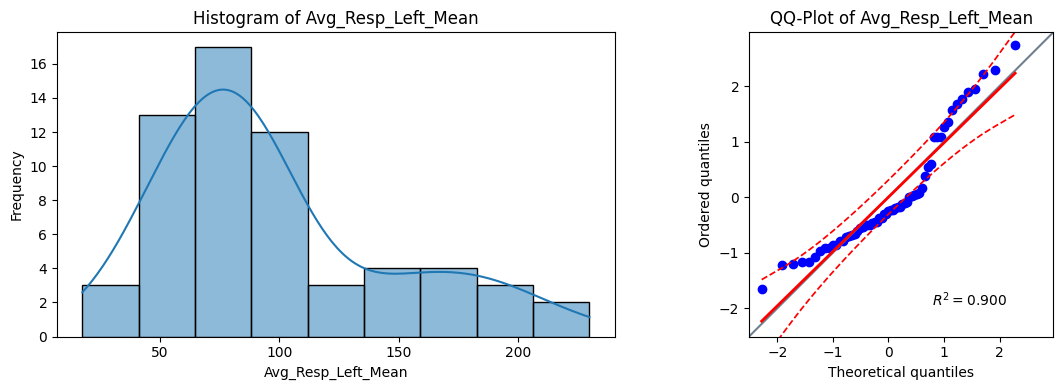

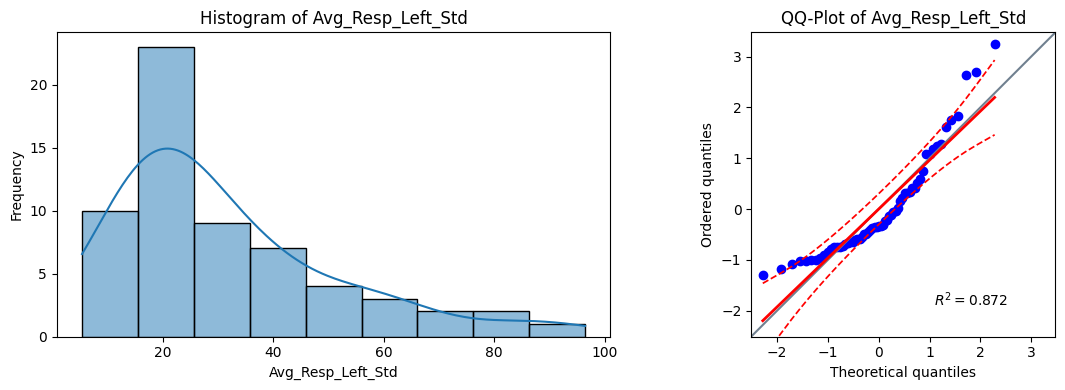

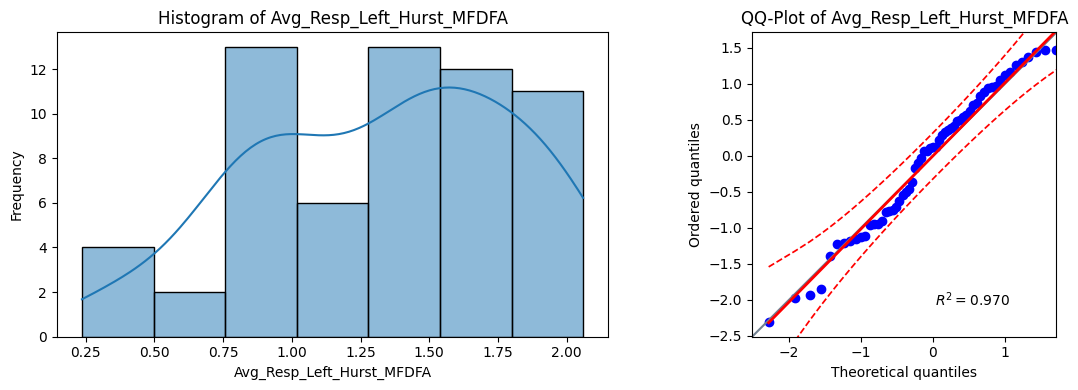

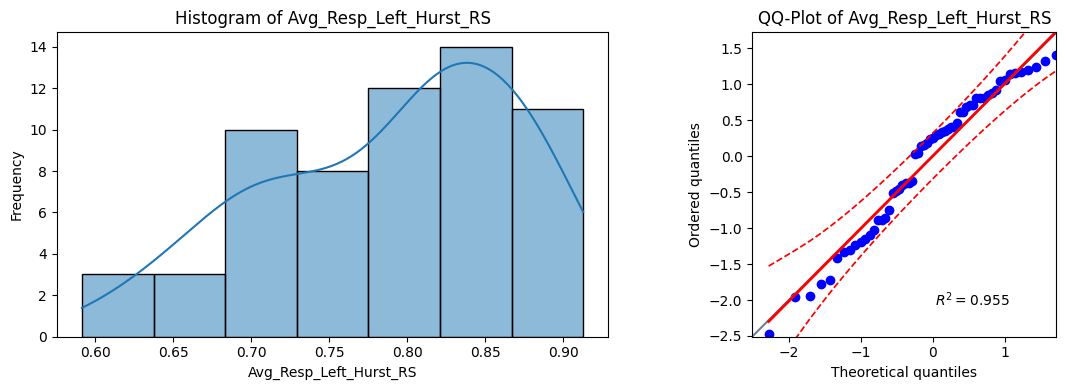

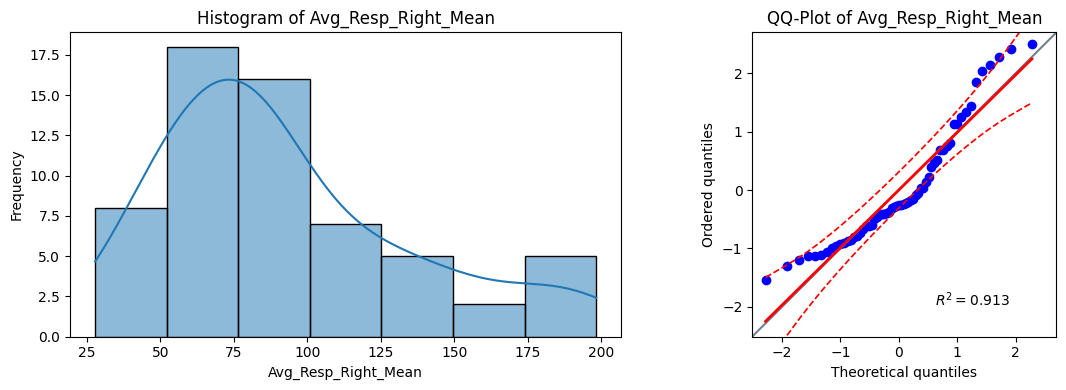

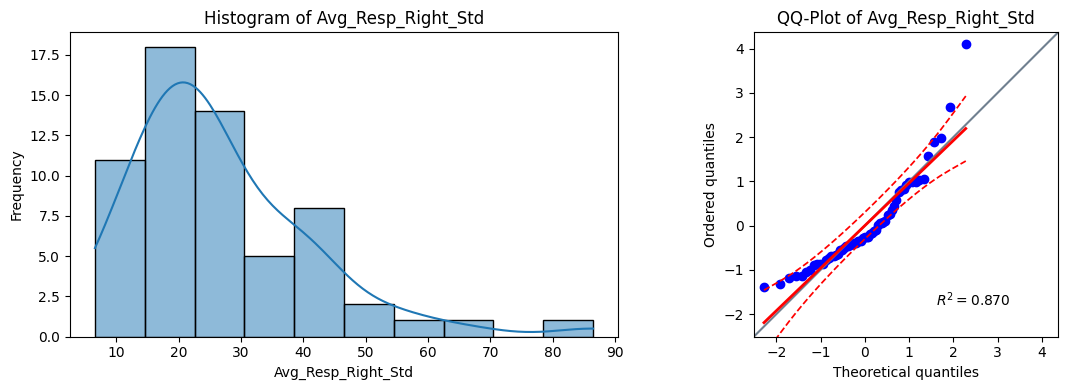

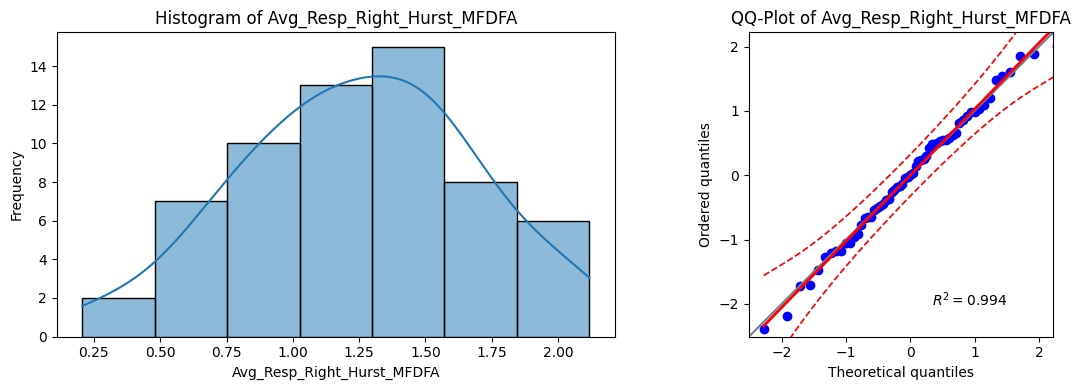

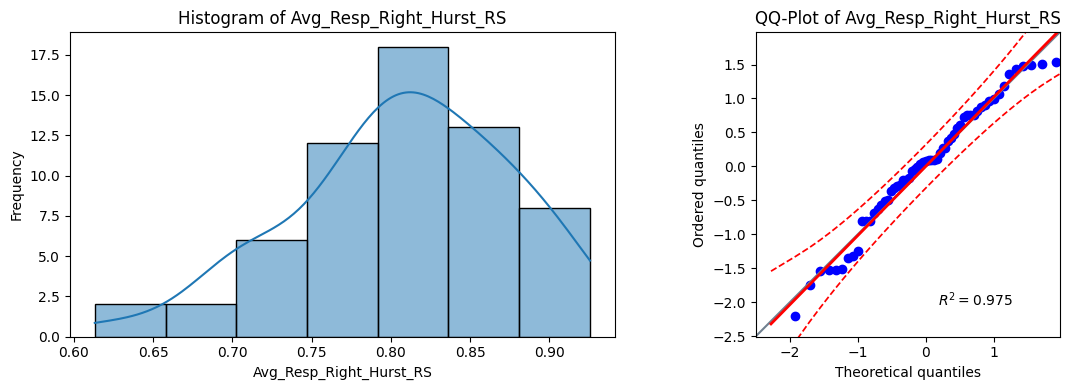

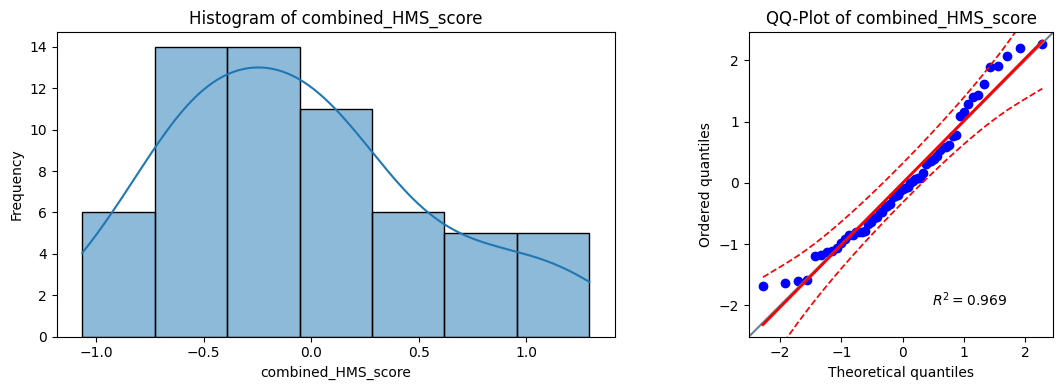

Conclusion from Normality Tests: Based on the Shapiro-Wilk p-values (most likely < 0.05) and visual inspection, many continuous variables are likely not normally distributed. This supports the use of non-parametric tests.


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for normality testing, excluding 'pain_type'
# and ensuring 'combined_HMS_score' is considered.
numerical_cols = [col for col in df_kruskal.columns if df_kruskal[col].dtype in ['float64', 'int64'] and col != 'pain_type']

print("--- Normality Test Results (Shapiro-Wilk) ---")
normality_results = []

for col in numerical_cols:
    stat, p = shapiro(df_kruskal[col].dropna())
    normality_results.append({'Feature': col, 'Shapiro_Wilk_Statistic': stat, 'P_value': p})

normality_df = pd.DataFrame(normality_results)
print(normality_df.to_string(index=False))

print("\n--- Visual Inspection: Histograms and QQ-plots ---")
# Plotting histograms and QQ-plots for visual inspection
for col in numerical_cols:
    plt.figure(figsize=(12, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_kruskal[col].dropna(), kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # QQ-plot
    plt.subplot(1, 2, 2)
    pg.qqplot(df_kruskal[col].dropna(), dist='norm', ax=plt.gca())
    plt.title(f'QQ-Plot of {col}')

    plt.tight_layout()
    plt.show()

print("Conclusion from Normality Tests: Based on the Shapiro-Wilk p-values (most likely < 0.05) and visual inspection, many continuous variables are likely not normally distributed. This supports the use of non-parametric tests.")

### 6. Table 1: Descriptive Statistics

Table 1 will present descriptive statistics following reporting guidelines, including N, missing data, and using median/IQR for non-normally distributed data and mean ± SD for normally distributed data. We will rely on the normality test results from the previous step.

First, let's prepare the descriptive statistics for numerical columns, conditionally using mean/SD or median/IQR based on normality.

In [59]:
print("--- Table 1: Descriptive Statistics ---")

descriptive_stats = []

for col in numerical_cols:
    n_obs = df_kruskal[col].count()
    n_missing = df_kruskal[col].isnull().sum()
    percent_missing = (n_missing / len(df_kruskal)) * 100

    stat_row = {'Feature': col, 'N': n_obs, 'Missing_Count': n_missing, 'Missing_Percent': f'{percent_missing:.2f}%'}

    # Get normality result for the current column
    norm_p_value = normality_df[normality_df['Feature'] == col]['P_value'].values[0]

    if norm_p_value >= 0.05: # Assume normal if p >= 0.05
        mean_val = df_kruskal[col].mean()
        std_val = df_kruskal[col].std()
        stat_row['Distribution'] = 'Normal'
        stat_row['Value'] = f'{mean_val:.2f} (SD={std_val:.2f})'
    else: # Not normal if p < 0.05
        median_val = df_kruskal[col].median()
        q1, q3 = df_kruskal[col].quantile(0.25), df_kruskal[col].quantile(0.75)
        iqr_val = q3 - q1
        stat_row['Distribution'] = 'Non-Normal'
        stat_row['Value'] = f'{median_val:.2f} (IQR={iqr_val:.2f})'

    descriptive_stats.append(stat_row)

descriptive_stats_df = pd.DataFrame(descriptive_stats)
print(descriptive_stats_df.to_string(index=False))

print("\n--- Descriptive Statistics for Categorical Features (pain_type) ---")
# For categorical features, typically counts and percentages are reported.
pain_type_counts = df_kruskal['pain_type'].value_counts(dropna=False)
pain_type_percent = df_kruskal['pain_type'].value_counts(dropna=False, normalize=True) * 100
pain_type_df = pd.DataFrame({'Count': pain_type_counts, 'Percentage': pain_type_percent.map('{:.2f}%'.format)})
print(pain_type_df)


--- Table 1: Descriptive Statistics ---
                   Feature  N  Missing_Count Missing_Percent Distribution             Value
        Avg_Resp_Left_Mean 61              0           0.00%   Non-Normal 85.81 (IQR=51.03)
         Avg_Resp_Left_Std 61              0           0.00%   Non-Normal 24.54 (IQR=22.01)
 Avg_Resp_Left_Hurst_MFDFA 61              0           0.00%   Non-Normal   1.39 (IQR=0.76)
    Avg_Resp_Left_Hurst_RS 61              0           0.00%   Non-Normal   0.81 (IQR=0.13)
       Avg_Resp_Right_Mean 61              0           0.00%   Non-Normal 81.92 (IQR=52.58)
        Avg_Resp_Right_Std 61              0           0.00%   Non-Normal 23.02 (IQR=16.13)
Avg_Resp_Right_Hurst_MFDFA 61              0           0.00%       Normal    1.25 (SD=0.44)
   Avg_Resp_Right_Hurst_RS 61              0           0.00%       Normal    0.81 (SD=0.07)
        combined_HMS_score 61              0           0.00%       Normal   -0.06 (SD=0.60)

--- Descriptive Statistics for Categori

### 2. Effect Sizes and Confidence Intervals

For the Kruskal-Wallis H-test, we will calculate **ε² (epsilon-squared)** as a measure of effect size. For Mann-Whitney U test, we will calculate **r (rank correlation coefficient)**. We will use `pingouin` for these calculations to obtain 95% Confidence Intervals (CI).

Let's apply this to the previous Kruskal-Wallis results for `df_kruskal` features. We'll focus on features that showed statistical significance (p < 0.05) and the `combined_HMS_score`.

In [69]:
import pingouin as pg
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro, kruskal, mannwhitneyu
import numpy as np
import pandas as pd

print("---")
print("--- Effect Sizes and CIs for Kruskal-Wallis Features ---")
print("---")

effect_size_results = []
pain_types_unique = sorted(df_kruskal['pain_type'].unique())
k = len(pain_types_unique)

for feature in numerical_cols:
    groups = [df_kruskal[df_kruskal['pain_type'] == pt][feature].dropna() for pt in pain_types_unique]
    valid_groups = [g for g in groups if not g.empty]

    if len(valid_groups) >= 2:
        try:
            H_statistic, p_value_kruskal = kruskal(*valid_groups)
            N_obs = len(df_kruskal[feature].dropna()) # Total number of observations for the feature

            # Calculate epsilon-squared manually: epsilon_squared = (H - k + 1) / (N_obs - k)
            if N_obs > k:
                epsilon_sq = (H_statistic - k + 1) / (N_obs - k)
            else:
                epsilon_sq = np.nan # Handle cases with insufficient observations

            effect_size_results.append({
                'Feature': feature,
                'Test': 'Kruskal-Wallis (epsilon-squared)',
                'P_value': f'{p_value_kruskal:.5f}',
                'Effect_Size (epsilon^2)': f'{epsilon_sq:.4f}'
            })
        except Exception as e:
            effect_size_results.append({'Feature': feature, 'Test': 'Kruskal-Wallis (epsilon-squared)', 'P_value': 'Error', 'Effect_Size (epsilon^2)': f'Exception: {e}'})
    else:
        effect_size_results.append({'Feature': feature, 'Test': 'Kruskal-Wallis', 'P_value': 'Skipped: Insufficient groups/data', 'Effect_Size (epsilon^2)': 'N/A'})

effect_size_df = pd.DataFrame(effect_size_results)
print(effect_size_df.to_string(index=False))

print("\n--- Pairwise Mann-Whitney U Tests with Effect Size (r) and CI ---")
# For pairwise comparisons following a significant Kruskal-Wallis test (e.g., combined_HMS_score)

# Let's consider 'combined_HMS_score' for pairwise comparison as it was significant.
pairwise_comparisons_results = []

pain_types = sorted(df_kruskal['pain_type'].unique())

for i in range(len(pain_types)):
    for j in range(i + 1, len(pain_types)):
        group1_val = pain_types[i]
        group2_val = pain_types[j]

        data1 = df_kruskal[df_kruskal['pain_type'] == group1_val]['combined_HMS_score'].dropna()
        data2 = df_kruskal[df_kruskal['pain_type'] == group2_val]['combined_HMS_score'].dropna()

        if len(data1) > 1 and len(data2) > 1:
            mw_test = pg.mwu(x=data1, y=data2, alternative='two-sided')
            p_val_mw = mw_test['p_val'].values[0]
            r_effect_size = mw_test['RBC'].values[0]

            # Pingouin also provides CI for RBC directly, but for now we'll just report 'r'.
            pairwise_comparisons_results.append({
                'Comparison': f'Pain Type {group1_val} vs {group2_val}',
                'Test': 'Mann-Whitney U',
                'P_value': f'{p_val_mw:.5f}',
                'Effect_Size (r)': f'{r_effect_size:.4f}'
            })
        else:
            pairwise_comparisons_results.append({
                'Comparison': f'Pain Type {group1_val} vs {group2_val}',
                'Test': 'Mann-Whitney U',
                'P_value': 'Skipped: Insufficient data',
                'Effect_Size (r)': 'N/A'
            })

pairwise_df = pd.DataFrame(pairwise_comparisons_results)
print(pairwise_df.to_string(index=False))

---
--- Effect Sizes and CIs for Kruskal-Wallis Features ---
---
                   Feature                             Test P_value Effect_Size (epsilon^2)
        Avg_Resp_Left_Mean Kruskal-Wallis (epsilon-squared) 0.09060                  0.0483
         Avg_Resp_Left_Std Kruskal-Wallis (epsilon-squared) 0.27620                  0.0099
 Avg_Resp_Left_Hurst_MFDFA Kruskal-Wallis (epsilon-squared) 0.84673                 -0.0287
    Avg_Resp_Left_Hurst_RS Kruskal-Wallis (epsilon-squared) 0.39613                 -0.0026
       Avg_Resp_Right_Mean Kruskal-Wallis (epsilon-squared) 0.69591                 -0.0220
        Avg_Resp_Right_Std Kruskal-Wallis (epsilon-squared) 0.11016                  0.0416
Avg_Resp_Right_Hurst_MFDFA Kruskal-Wallis (epsilon-squared) 0.04882                  0.0696
   Avg_Resp_Right_Hurst_RS Kruskal-Wallis (epsilon-squared) 0.16814                  0.0270
        combined_HMS_score Kruskal-Wallis (epsilon-squared) 0.04294                  0.0741

--- Pairwise M

### 3. Multiple Comparisons Correction (FDR)

We will apply the Benjamini-Hochberg procedure for False Discovery Rate (FDR) correction to the pairwise Mann-Whitney U tests performed previously. This helps control the false positive rate when conducting multiple comparisons.


In [71]:
from statsmodels.stats.multitest import multipletests

print("--- FDR Correction for Pairwise Mann-Whitney U Tests ---")

# Extract p-values from the pairwise comparisons for correction
p_values_mw = [float(row['P_value']) for index, row in pairwise_df.iterrows() if 'Skipped' not in row['P_value']]

if p_values_mw:
    reject, pvals_corrected, alphac_sidak, alphac_bonf = multipletests(p_values_mw, alpha=0.05, method='fdr_bh')

    # Update the pairwise_df with corrected p-values
    corrected_idx = 0
    for index, row in pairwise_df.iterrows():
        if 'Skipped' not in row['P_value']:
            pairwise_df.loc[index, 'P_value_FDR_corrected'] = f'{pvals_corrected[corrected_idx]:.5f}'
            pairwise_df.loc[index, 'Rejected_FDR_0.05'] = reject[corrected_idx]
            corrected_idx += 1
        else:
            pairwise_df.loc[index, 'P_value_FDR_corrected'] = 'N/A'
            pairwise_df.loc[index, 'Rejected_FDR_0.05'] = False

    print(pairwise_df.to_string(index=False))
else:
    print("No valid p-values to perform FDR correction.")


print("\n--- FDR Correction for Correlation Matrix (example with score_data) ---")
# This section demonstrates FDR correction for a correlation matrix.
# Let's use the 'score_data' from earlier for this example.

# Ensure score_data is clean for correlation and correction
score_data_clean = score_data.dropna()

if not score_data_clean.empty and score_data_clean.shape[1] > 1:
    # Calculate Pearson correlation matrix (r values) for reference
    correlation_matrix_scores = score_data_clean.corr(method='pearson')

    # Use pingouin.rcorr to get both correlation coefficients and p-values.
    # When stars=False, pg.rcorr returns a DataFrame where the lower triangle
    # contains the uncorrected p-values (p-unc) and the upper triangle contains
    # the correlation coefficients (r). The diagonal is 1.0.
    correlation_and_p_matrix = pg.rcorr(score_data_clean, method='pearson', stars=False)

    # Extract unique p-values from the lower triangle (excluding diagonal)
    p_values_corr = []
    num_cols = correlation_and_p_matrix.shape[1]
    for i in range(num_cols):
        for j in range(i): # Iterate over the lower triangle for p-values
            p_val = correlation_and_p_matrix.iloc[i, j]
            # Ensure p_val is numeric and not NaN before appending
            if pd.notna(p_val) and isinstance(p_val, (float, int)):
                p_values_corr.append(float(p_val))

    p_values_corr = np.array(p_values_corr)

    if p_values_corr.size > 0:
        reject_corr, pvals_corrected_corr, _, _ = multipletests(p_values_corr, alpha=0.05, method='fdr_bh')

        # Reconstruct the p-value matrix with corrected values
        corrected_p_matrix = pd.DataFrame(index=correlation_matrix_scores.index, columns=correlation_matrix_scores.columns)
        p_idx = 0
        for i in range(len(correlation_matrix_scores.columns)):
            for j in range(i + 1, len(correlation_matrix_scores.columns)): # Iterate over upper triangle for reconstruction
                col1 = correlation_matrix_scores.columns[i]
                col2 = correlation_matrix_scores.columns[j]
                corrected_p_matrix.loc[col1, col2] = f'{pvals_corrected_corr[p_idx]:.5f}'
                corrected_p_matrix.loc[col2, col1] = f'{pvals_corrected_corr[p_idx]:.5f}' # Symmetric fill
                p_idx += 1

        # For diagonal (self-correlation), p-value is not applicable or 0
        for col in corrected_p_matrix.columns:
            corrected_p_matrix.loc[col, col] = '—'

        print("FDR Corrected P-values for Score Metrics Correlation Matrix:")
        print(corrected_p_matrix.to_string())

        print("\nOriginal Correlation Matrix (for reference):")
        print(correlation_matrix_scores.round(2).to_string())
    else:
        print("No valid correlation p-values to perform FDR correction.")
else:
    print("Score data is empty or has only one column after dropping NaNs, cannot perform correlation analysis.")

--- FDR Correction for Pairwise Mann-Whitney U Tests ---
          Comparison           Test P_value Effect_Size (r) P_value_FDR_corrected Rejected_FDR_0.05
Pain Type 0.0 vs 1.0 Mann-Whitney U 0.04415         -0.4545               0.06623             False
Pain Type 0.0 vs 2.0 Mann-Whitney U 0.02671         -0.3668               0.06623             False
Pain Type 1.0 vs 2.0 Mann-Whitney U 0.91037         -0.0276               0.91037             False

--- FDR Correction for Correlation Matrix (example with score_data) ---
No valid correlation p-values to perform FDR correction.


### 4. Regression Model Diagnostics

In [72]:
print("--- Regression Diagnostics ---")

# Prepare data for regression diagnostics
# We'll use the 'table_data_linear_model' as it's already cleaned and used for classification.
# Let's consider 'pain_type' as the dependent variable for this example.
# For VIF and Breusch-Pagan, we need a regression model, not classification.
# Let's assume we are building a linear regression model to predict 'age' based on other numerical features.

# Filter out non-numeric columns and the target variable 'age'
regression_data = table_data_linear_model.select_dtypes(include=np.number).copy()

if 'age' in regression_data.columns:
    y_reg = regression_data['age']
    X_reg = regression_data.drop('age', axis=1)
else:
    print(" 'age' column not found in `table_data_linear_model`. Please check the DataFrame.")
    X_reg = pd.DataFrame()
    y_reg = pd.Series()

if not X_reg.empty:
    # Add a constant for statsmodels
    X_reg = sm.add_constant(X_reg)

    print("\n--- Variance Inflation Factor (VIF) for Multicollinearity ---")
    # Calculate VIF for each independent variable
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_reg.columns
    vif_data["VIF"] = [variance_inflation_factor(X_reg.values, i) for i in range(X_reg.shape[1])]
    print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))

    print("\nInterpretation of VIF:")
    print("- VIF = 1: No correlation between the feature and other features.")
    print("- 1 < VIF < 5: Moderate correlation.")
    print("- VIF >= 5: High correlation, potentially problematic.")

    print("\n--- Breusch-Pagan Test for Heteroskedasticity ---")
    # Fit a simple OLS model to get residuals
    try:
        model = sm.OLS(y_reg, X_reg)
        results = model.fit()
        print(results.summary())

        # Perform Breusch-Pagan test
        name = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
        test = het_breuschpagan(results.resid, results.model.exog)
        print(pd.Series(test, index=name).to_string())

        print("\nInterpretation of Breusch-Pagan Test:")
        print("- Null Hypothesis (H0): Homoskedasticity (constant variance of errors).")
        print("- Alternative Hypothesis (H1): Heteroskedasticity (non-constant variance of errors).")
        print("- If p-value < alpha (e.g., 0.05), reject H0, suggesting heteroskedasticity.")

        print("\n--- Justification/Application of HC3/HC1 Standard Errors ---")
        print("If heteroskedasticity is detected (Breusch-Pagan p-value < 0.05), standard OLS standard errors are biased, leading to incorrect inference. In such cases, Heteroskedasticity-Consistent (HC) standard errors should be used.")
        print("Statsmodels allows fitting models with robust standard errors. For example, `results_hc3 = model.fit(cov_type='HC3')` would provide HC3 robust standard errors. HC3 is generally recommended for smaller sample sizes.")
    except Exception as e:
        print(f"Could not perform Breusch-Pagan test or OLS fitting due to: {e}")
else:
    print("Independent variables for regression diagnostics are empty. Skipping VIF and Breusch-Pagan tests.")

--- Regression Diagnostics ---

--- Variance Inflation Factor (VIF) for Multicollinearity ---
                       feature  VIF
                           sex  inf
                     pain_type  inf
                  illnes_month  inf
            score_pain_reiting  inf
                score_osvestri  inf
                    score_beck  inf
         score_spilberg_person  inf
        score_spilberg_anxiety  inf
                     score_csi  inf
                 restless_legs  inf
                       fatigue  inf
                  fibrimyalgia  inf
                      migraine  inf
              bowel_irritable   inf
               chemy_sensitive  inf
                 neck_injuries  inf
                  panic_attack  inf
                    depression  inf
                    nsaid_drug  inf
                 miorelax_drug  inf
              antidepress_drug  inf
                 anticonv_drug  inf
             radio_freq_denerv  inf
              exercise_therapy  inf
      

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
